# 🏢 B2B Customer Segmentation — Marketo + Salesforce Integration

## Real-World Scenario
**Company:** TechNova Solutions — a mid-market B2B SaaS company selling an enterprise analytics platform.  
**Challenge:** The marketing and sales teams operate in silos. Marketo captures engagement data (emails, webinars, content downloads), while Salesforce holds the CRM pipeline (accounts, opportunities, deal stages). Leadership wants a unified segmentation model to:
1. Identify high-value accounts for ABM campaigns
2. Detect at-risk accounts before churn
3. Prioritize sales outreach using data-driven tiers
4. Align marketing spend to account potential

## Architecture
```
┌─────────────┐     ┌──────────────┐
│   MARKETO    │     │  SALESFORCE   │
│ (Engagement) │     │   (CRM/Pipeline)│
└──────┬──────┘     └──────┬───────┘
       │                    │
       ▼                    ▼
  ┌──────────────────────────────┐
  │  DATA MERGE (Account-Level)  │
  └──────────────┬───────────────┘
                 ▼
  ┌──────────────────────────────┐
  │  FEATURE ENGINEERING         │
  │  - Firmographic features     │
  │  - Engagement scores         │
  │  - Pipeline metrics          │
  │  - Recency/Frequency/Monetary│
  └──────────────┬───────────────┘
                 ▼
  ┌──────────────────────────────┐
  │  ADVANCED SEGMENTATION       │
  │  - RFM Analysis              │
  │  - K-Means Clustering        │
  │  - Hierarchical Clustering   │
  │  - DBSCAN (Anomaly Detection)│
  │  - Gaussian Mixture Models   │
  └──────────────┬───────────────┘
                 ▼
  ┌──────────────────────────────┐
  │  SEGMENT PROFILING & ACTION  │
  └──────────────────────────────┘
```

---

## Step 1 — Environment Setup & Library Installation

In [1]:
# ============================================================
# STEP 1: Install & Import Libraries
# ============================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn scipy yellowbrick kneed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Clustering & ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from kneed import KneeLocator

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ All libraries loaded successfully.')
print(f'📅 Analysis Date: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

✅ All libraries loaded successfully.
📅 Analysis Date: 2026-06-23 05:05


---
## Step 2 — Synthetic Data Generation (Mimicking Real Marketo + Salesforce Exports)

### 2A: Salesforce Account & Opportunity Data
In a real scenario, this would be extracted via:
- **Salesforce SOQL**: `SELECT Id, Name, Industry, AnnualRevenue, ... FROM Account`
- **Salesforce Data Loader** or **Salesforce Reports API**
- **Marketo REST API**: `GET /rest/v1/leads.json` with activity logs

In [2]:
# ============================================================
# STEP 2A: Generate Salesforce Account Data
# Mimics: SFDC Account object + Opportunity rollups
# ============================================================
np.random.seed(42)
N_ACCOUNTS = 2500  # Realistic mid-market B2B account base

# --- Salesforce Account Fields ---
industries = ['Technology', 'Financial Services', 'Healthcare', 'Manufacturing',
              'Retail', 'Education', 'Energy', 'Media & Entertainment',
              'Professional Services', 'Government']
industry_weights = [0.22, 0.15, 0.13, 0.12, 0.10, 0.08, 0.06, 0.05, 0.05, 0.04]

company_sizes = ['1-50', '51-200', '201-500', '501-1000', '1001-5000', '5000+']
size_weights = [0.15, 0.25, 0.22, 0.18, 0.12, 0.08]

regions = ['North America', 'EMEA', 'APAC', 'LATAM']
region_weights = [0.45, 0.25, 0.20, 0.10]

account_tiers_sfdc = ['Enterprise', 'Mid-Market', 'SMB']
tier_weights = [0.15, 0.35, 0.50]

lead_sources = ['Inbound - Web', 'Outbound - SDR', 'Partner Referral',
                'Event/Conference', 'Content Syndication', 'Paid Media']

# Generate account IDs matching Salesforce format
sf_account_ids = [f'001{str(i).zfill(12)}' for i in range(1, N_ACCOUNTS + 1)]

# Create Salesforce Accounts DataFrame
sf_accounts = pd.DataFrame({
    'sf_account_id': sf_account_ids,
    'account_name': [f'Account_{i}' for i in range(1, N_ACCOUNTS + 1)],
    'industry': np.random.choice(industries, N_ACCOUNTS, p=industry_weights),
    'company_size': np.random.choice(company_sizes, N_ACCOUNTS, p=size_weights),
    'region': np.random.choice(regions, N_ACCOUNTS, p=region_weights),
    'account_tier': np.random.choice(account_tiers_sfdc, N_ACCOUNTS, p=tier_weights),
    'annual_revenue_usd': np.zeros(N_ACCOUNTS),  # Will populate below
    'employee_count': np.zeros(N_ACCOUNTS, dtype=int),
    'account_created_date': pd.NaT,
    'account_owner': np.random.choice(
        ['Sarah_Chen', 'Mike_Johnson', 'Priya_Patel', 'James_Wilson',
         'Lisa_Garcia', 'Tom_Anderson', 'Nina_Kowalski'], N_ACCOUNTS
    ),
    'lead_source': np.random.choice(lead_sources, N_ACCOUNTS),
})

# Realistic revenue & employee count correlated with company size
size_revenue_map = {
    '1-50': (500_000, 5_000_000),
    '51-200': (5_000_000, 25_000_000),
    '201-500': (25_000_000, 100_000_000),
    '501-1000': (100_000_000, 500_000_000),
    '1001-5000': (500_000_000, 2_000_000_000),
    '5000+': (2_000_000_000, 50_000_000_000)
}
size_emp_map = {
    '1-50': (5, 50), '51-200': (51, 200), '201-500': (201, 500),
    '501-1000': (501, 1000), '1001-5000': (1001, 5000), '5000+': (5001, 50000)
}

for size, (rev_lo, rev_hi) in size_revenue_map.items():
    mask = sf_accounts['company_size'] == size
    n = mask.sum()
    sf_accounts.loc[mask, 'annual_revenue_usd'] = np.random.lognormal(
        mean=np.log((rev_lo + rev_hi) / 2), sigma=0.5, size=n
    ).clip(rev_lo, rev_hi * 1.5)
    emp_lo, emp_hi = size_emp_map[size]
    sf_accounts.loc[mask, 'employee_count'] = np.random.randint(emp_lo, emp_hi + 1, n)

# Account creation dates spanning 4 years
base_date = datetime(2020, 1, 1)
sf_accounts['account_created_date'] = [
    base_date + timedelta(days=int(d))
    for d in np.random.uniform(0, 1460, N_ACCOUNTS)
]

print(f'✅ Salesforce Accounts generated: {sf_accounts.shape}')
sf_accounts.head(3)

✅ Salesforce Accounts generated: (2500, 11)


,sf_account_id,account_name,industry,company_size,region,account_tier,annual_revenue_usd,employee_count,account_created_date,account_owner,lead_source
0,001000000000001,Account_1,Healthcare,1001-5000,North America,SMB,1.998564e+09,3208,2021-06-30,Nina_Kowalski,Event/Conference
1,001000000000002,Account_2,Professional Services,501-1000,EMEA,SMB,6.288382e+08,638,2021-02-16,James_Wilson,Event/Conference
2,001000000000003,Account_3,Education,201-500,APAC,Enterprise,5.396834e+07,204,2021-12-29,Mike_Johnson,Inbound - Web


In [3]:
# ============================================================
# STEP 2B: Generate Salesforce Opportunity Data
# Mimics: SFDC Opportunity object
# ============================================================
opp_stages = ['Prospecting', 'Qualification', 'Proposal', 'Negotiation',
              'Closed Won', 'Closed Lost']

opportunities = []
for _, acct in sf_accounts.iterrows():
    n_opps = np.random.choice([0, 1, 2, 3, 4, 5], p=[0.15, 0.30, 0.25, 0.15, 0.10, 0.05])
    for j in range(n_opps):
        tier = acct['account_tier']
        if tier == 'Enterprise':
            deal_val = np.random.lognormal(mean=np.log(150000), sigma=0.6)
        elif tier == 'Mid-Market':
            deal_val = np.random.lognormal(mean=np.log(45000), sigma=0.5)
        else:
            deal_val = np.random.lognormal(mean=np.log(12000), sigma=0.4)

        stage = np.random.choice(opp_stages, p=[0.10, 0.15, 0.20, 0.15, 0.25, 0.15])
        close_date = acct['account_created_date'] + timedelta(
            days=int(np.random.uniform(30, 365))
        )
        opportunities.append({
            'sf_account_id': acct['sf_account_id'],
            'opportunity_id': f'006{np.random.randint(100000000, 999999999)}',
            'opportunity_name': f"{acct['account_name']}_Opp_{j+1}",
            'stage': stage,
            'amount_usd': round(deal_val, 2),
            'close_date': close_date,
            'probability': {'Prospecting': 10, 'Qualification': 25, 'Proposal': 50,
                            'Negotiation': 75, 'Closed Won': 100, 'Closed Lost': 0}[stage],
            'product_line': np.random.choice(
                ['Analytics Pro', 'Analytics Enterprise', 'Data Platform',
                 'Custom Integration', 'Managed Services']
            ),
            'contract_term_months': np.random.choice([12, 24, 36], p=[0.40, 0.35, 0.25]),
            'discount_pct': np.random.choice([0, 5, 10, 15, 20, 25], p=[0.30, 0.20, 0.20, 0.15, 0.10, 0.05]),
        })

sf_opportunities = pd.DataFrame(opportunities)
print(f'✅ Salesforce Opportunities generated: {sf_opportunities.shape}')
print(f'   Total pipeline value: ${sf_opportunities["amount_usd"].sum():,.0f}')
sf_opportunities.head(3)

✅ Salesforce Opportunities generated: (4800, 10)
   Total pipeline value: $252,692,561


,sf_account_id,opportunity_id,opportunity_name,stage,amount_usd,close_date,probability,product_line,contract_term_months,discount_pct
0,001000000000001,006153231418,Account_1_Opp_1,Proposal,14202.56,2022-01-17,50,Data Platform,12,5
1,001000000000001,006252252294,Account_1_Opp_2,Closed Lost,8720.67,2022-01-18,0,Analytics Enterprise,36,0
2,001000000000001,006780415246,Account_1_Opp_3,Closed Won,11313.88,2022-06-02,100,Custom Integration,36,0


In [4]:
# ============================================================
# STEP 2C: Generate Marketo Engagement Data
# Mimics: Marketo Activity Logs + Lead Database
# ============================================================
# In Marketo, leads are associated with SFDC accounts via Account ID sync
# We generate lead-level activity then roll up to account level

marketo_activities = []
activity_types = [
    'Email Opened', 'Email Clicked', 'Email Bounced', 'Email Unsubscribed',
    'Form Submitted', 'Web Page Visited', 'Webinar Registered',
    'Webinar Attended', 'Content Downloaded', 'Demo Requested',
    'Pricing Page Visited', 'Case Study Downloaded'
]

for _, acct in sf_accounts.iterrows():
    # Number of leads per account (more leads for larger companies)
    size = acct['company_size']
    if size in ['5000+', '1001-5000']:
        n_leads = np.random.randint(5, 20)
    elif size in ['501-1000', '201-500']:
        n_leads = np.random.randint(2, 10)
    else:
        n_leads = np.random.randint(1, 5)

    for lead in range(n_leads):
        lead_id = f'LID{np.random.randint(1000000, 9999999)}'
        # Each lead has multiple activities over 12 months
        n_activities = np.random.poisson(lam=8)
        for _ in range(max(1, n_activities)):
            activity_date = datetime(2024, 1, 1) + timedelta(
                days=int(np.random.uniform(0, 365))
            )
            marketo_activities.append({
                'sf_account_id': acct['sf_account_id'],
                'marketo_lead_id': lead_id,
                'activity_type': np.random.choice(activity_types,
                    p=[0.25, 0.12, 0.03, 0.02, 0.10, 0.18, 0.06,
                       0.04, 0.08, 0.03, 0.05, 0.04]
                ),
                'activity_date': activity_date,
                'campaign_name': np.random.choice([
                    'Q1_Product_Launch', 'Nurture_Series_A', 'ABM_Enterprise',
                    'Webinar_DataTrends', 'Content_Whitepaper', 'Event_Follow_Up',
                    'Re-engagement_Campaign', 'Competitive_Takeout',
                    'Newsletter_Monthly', 'Partner_Co-marketing'
                ]),
                'lead_score': np.random.randint(1, 100),
                'lead_status': np.random.choice(
                    ['New', 'MQL', 'SQL', 'SAL', 'Recycled', 'Disqualified'],
                    p=[0.20, 0.25, 0.20, 0.15, 0.12, 0.08]
                ),
            })

mkto_activities = pd.DataFrame(marketo_activities)
mkto_activities['activity_date'] = pd.to_datetime(mkto_activities['activity_date'])

print(f'✅ Marketo Activities generated: {mkto_activities.shape}')
print(f'   Unique leads: {mkto_activities["marketo_lead_id"].nunique():,}')
print(f'   Activity types: {mkto_activities["activity_type"].nunique()}')
mkto_activities.head(3)

✅ Marketo Activities generated: (112282, 7)
   Unique leads: 14,013
   Activity types: 12


,sf_account_id,marketo_lead_id,activity_type,activity_date,campaign_name,lead_score,lead_status
0,001000000000001,LID8471267,Email Opened,2024-08-11,ABM_Enterprise,46,MQL
1,001000000000001,LID8471267,Email Opened,2024-10-15,Content_Whitepaper,6,New
2,001000000000001,LID8471267,Email Clicked,2024-05-31,Re-engagement_Campaign,25,SQL


---
## Step 3 — Data Validation & Quality Checks
Before merging, we validate each source for completeness, consistency, and join-key integrity.

In [5]:
# ============================================================
# STEP 3: Data Validation Suite
# ============================================================
def validate_dataset(df, name, key_col):
    """Comprehensive data quality report."""
    print(f'\n{"=" * 60}')
    print(f'📊 DATA VALIDATION REPORT: {name}')
    print(f'{"=" * 60}')
    print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print(f'\n--- Column Types ---')
    print(df.dtypes.value_counts().to_string())
    print(f'\n--- Missing Values ---')
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({'count': missing, 'pct': missing_pct})
    print(missing_report[missing_report['count'] > 0].to_string() if missing.any() else '  ✅ No missing values')
    print(f'\n--- Key Column: {key_col} ---')
    print(f'  Unique: {df[key_col].nunique():,}')
    print(f'  Duplicates: {df[key_col].duplicated().sum():,}')
    print(f'  Nulls: {df[key_col].isnull().sum()}')

    # Numeric summary
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        print(f'\n--- Numeric Summary ---')
        print(df[num_cols].describe().round(2).to_string())

    return True

# Validate all three datasets
validate_dataset(sf_accounts, 'Salesforce Accounts', 'sf_account_id')
validate_dataset(sf_opportunities, 'Salesforce Opportunities', 'sf_account_id')
validate_dataset(mkto_activities, 'Marketo Activities', 'sf_account_id')


📊 DATA VALIDATION REPORT: Salesforce Accounts
Shape: 2,500 rows × 11 columns
Memory: 1.20 MB

--- Column Types ---
object            8
float64           1
int64             1
datetime64[ns]    1

--- Missing Values ---
  ✅ No missing values

--- Key Column: sf_account_id ---
  Unique: 2,500
  Duplicates: 0
  Nulls: 0

--- Numeric Summary ---
       annual_revenue_usd  employee_count
count        2.500000e+03         2500.00
mean         2.480062e+09         2658.80
std          8.557294e+09         7799.99
min          6.745475e+05            5.00
25%          1.303441e+07          110.00
50%          5.540803e+07          316.00
75%          4.145187e+08          858.00
max          7.500000e+10        49683.00

📊 DATA VALIDATION REPORT: Salesforce Opportunities
Shape: 4,800 rows × 10 columns
Memory: 1.85 MB

--- Column Types ---
object            5
int64             3
float64           1
datetime64[ns]    1

--- Missing Values ---
  ✅ No missing values

--- Key Column: sf_account_id

True

In [6]:
# ============================================================
# STEP 3B: Join Key Integrity Check
# ============================================================
sf_acct_ids = set(sf_accounts['sf_account_id'])
opp_acct_ids = set(sf_opportunities['sf_account_id'])
mkto_acct_ids = set(mkto_activities['sf_account_id'])

print('🔗 JOIN KEY INTEGRITY')
print(f'  Accounts in SF:         {len(sf_acct_ids):,}')
print(f'  Accounts in Opps:       {len(opp_acct_ids):,}')
print(f'  Accounts in Marketo:    {len(mkto_acct_ids):,}')
print(f'  Opps → SF match rate:   {len(opp_acct_ids & sf_acct_ids) / len(opp_acct_ids) * 100:.1f}%')
print(f'  Marketo → SF match rate:{len(mkto_acct_ids & sf_acct_ids) / len(mkto_acct_ids) * 100:.1f}%')
print(f'  All three overlap:      {len(sf_acct_ids & opp_acct_ids & mkto_acct_ids):,} accounts')
print(f'\n✅ Data validation complete — safe to merge.')

🔗 JOIN KEY INTEGRITY
  Accounts in SF:         2,500
  Accounts in Opps:       2,121
  Accounts in Marketo:    2,500
  Opps → SF match rate:   100.0%
  Marketo → SF match rate:100.0%
  All three overlap:      2,121 accounts

✅ Data validation complete — safe to merge.


In [7]:
# ============================================================
# STEP 3C: Variable Dictionary (Data Catalog)
# ============================================================
variable_catalog = pd.DataFrame([
    # Salesforce Account
    ['sf_account_id', 'Salesforce', 'Unique account identifier', 'String', 'Join Key'],
    ['industry', 'Salesforce', 'Company industry vertical', 'Categorical', 'Firmographic'],
    ['company_size', 'Salesforce', 'Employee band', 'Ordinal', 'Firmographic'],
    ['region', 'Salesforce', 'Geographic region', 'Categorical', 'Firmographic'],
    ['account_tier', 'Salesforce', 'Enterprise/Mid-Market/SMB', 'Ordinal', 'Firmographic'],
    ['annual_revenue_usd', 'Salesforce', 'Company annual revenue', 'Continuous', 'Firmographic'],
    ['employee_count', 'Salesforce', 'Number of employees', 'Discrete', 'Firmographic'],
    ['lead_source', 'Salesforce', 'Original acquisition channel', 'Categorical', 'Attribution'],
    # Salesforce Opportunities
    ['stage', 'Salesforce', 'Opportunity stage', 'Ordinal', 'Pipeline'],
    ['amount_usd', 'Salesforce', 'Deal value in USD', 'Continuous', 'Pipeline'],
    ['probability', 'Salesforce', 'Close probability %', 'Continuous', 'Pipeline'],
    ['contract_term_months', 'Salesforce', 'Contract length', 'Discrete', 'Pipeline'],
    ['discount_pct', 'Salesforce', 'Discount offered', 'Continuous', 'Pipeline'],
    # Marketo Activities
    ['activity_type', 'Marketo', 'Type of engagement event', 'Categorical', 'Engagement'],
    ['lead_score', 'Marketo', 'Marketo lead score (1-100)', 'Continuous', 'Engagement'],
    ['lead_status', 'Marketo', 'MQL/SQL/SAL lifecycle stage', 'Ordinal', 'Engagement'],
    ['campaign_name', 'Marketo', 'Marketing campaign', 'Categorical', 'Engagement'],
], columns=['Variable', 'Source', 'Description', 'Type', 'Category'])

print('📋 VARIABLE CATALOG')
print(variable_catalog.to_string(index=False))

📋 VARIABLE CATALOG
            Variable     Source                  Description        Type     Category
       sf_account_id Salesforce    Unique account identifier      String     Join Key
            industry Salesforce    Company industry vertical Categorical Firmographic
        company_size Salesforce                Employee band     Ordinal Firmographic
              region Salesforce            Geographic region Categorical Firmographic
        account_tier Salesforce    Enterprise/Mid-Market/SMB     Ordinal Firmographic
  annual_revenue_usd Salesforce       Company annual revenue  Continuous Firmographic
      employee_count Salesforce          Number of employees    Discrete Firmographic
         lead_source Salesforce Original acquisition channel Categorical  Attribution
               stage Salesforce            Opportunity stage     Ordinal     Pipeline
          amount_usd Salesforce            Deal value in USD  Continuous     Pipeline
         probability Salesforce    

---
## Step 4 — Data Merging & Feature Engineering
We merge Marketo engagement data and Salesforce opportunity data at the **account level** to create a unified feature matrix.

In [8]:
# ============================================================
# STEP 4A: Roll Up Opportunity Data to Account Level
# ============================================================
opp_rollup = sf_opportunities.groupby('sf_account_id').agg(
    total_opportunities=('opportunity_id', 'count'),
    total_pipeline_value=('amount_usd', 'sum'),
    avg_deal_size=('amount_usd', 'mean'),
    max_deal_size=('amount_usd', 'max'),
    won_deals=('stage', lambda x: (x == 'Closed Won').sum()),
    lost_deals=('stage', lambda x: (x == 'Closed Lost').sum()),
    open_deals=('stage', lambda x: x.isin(['Prospecting','Qualification','Proposal','Negotiation']).sum()),
    avg_probability=('probability', 'mean'),
    avg_contract_months=('contract_term_months', 'mean'),
    avg_discount=('discount_pct', 'mean'),
    latest_close_date=('close_date', 'max'),
).reset_index()

# Derived pipeline metrics
opp_rollup['win_rate'] = (opp_rollup['won_deals'] /
    opp_rollup['total_opportunities'].clip(lower=1) * 100).round(2)
opp_rollup['weighted_pipeline'] = (
    opp_rollup['total_pipeline_value'] * opp_rollup['avg_probability'] / 100
).round(2)

print(f'✅ Opportunity rollup: {opp_rollup.shape}')
opp_rollup.head(3)

✅ Opportunity rollup: (2121, 14)


,sf_account_id,total_opportunities,total_pipeline_value,avg_deal_size,max_deal_size,won_deals,lost_deals,open_deals,avg_probability,avg_contract_months,avg_discount,latest_close_date,win_rate,weighted_pipeline
0,001000000000001,5,64724.66,12944.9320,21158.79,2,1,2,55.0,26.4,4.00,2022-06-04,40.0,35598.56
1,001000000000002,4,35085.67,8771.4175,10657.24,1,2,1,37.5,24.0,11.25,2022-01-24,25.0,13157.13
2,001000000000003,1,82462.96,82462.9600,82462.96,0,0,1,10.0,36.0,0.00,2022-03-08,0.0,8246.30


In [9]:
# ============================================================
# STEP 4B: Roll Up Marketo Activities to Account Level
# ============================================================
reference_date = datetime(2024, 12, 31)

# Activity counts by type (pivot)
activity_pivot = mkto_activities.groupby(
    ['sf_account_id', 'activity_type']
).size().unstack(fill_value=0).reset_index()

# Clean column names
activity_pivot.columns = ['sf_account_id'] + [
    col.lower().replace(' ', '_') + '_count'
    for col in activity_pivot.columns[1:]
]

# Aggregated engagement metrics
mkto_rollup = mkto_activities.groupby('sf_account_id').agg(
    total_activities=('activity_type', 'count'),
    unique_leads=('marketo_lead_id', 'nunique'),
    avg_lead_score=('lead_score', 'mean'),
    max_lead_score=('lead_score', 'max'),
    unique_campaigns=('campaign_name', 'nunique'),
    last_activity_date=('activity_date', 'max'),
    first_activity_date=('activity_date', 'min'),
    mql_count=('lead_status', lambda x: (x == 'MQL').sum()),
    sql_count=('lead_status', lambda x: (x == 'SQL').sum()),
    sal_count=('lead_status', lambda x: (x == 'SAL').sum()),
).reset_index()

# Recency in days
mkto_rollup['days_since_last_activity'] = (
    reference_date - mkto_rollup['last_activity_date']
).dt.days
mkto_rollup['engagement_span_days'] = (
    mkto_rollup['last_activity_date'] - mkto_rollup['first_activity_date']
).dt.days
mkto_rollup['activity_per_lead'] = (
    mkto_rollup['total_activities'] / mkto_rollup['unique_leads']
).round(2)

# Merge activity pivot with rollup
mkto_full = mkto_rollup.merge(activity_pivot, on='sf_account_id', how='left')

print(f'✅ Marketo rollup: {mkto_full.shape}')
mkto_full.head(3)

✅ Marketo rollup: (2500, 26)


,sf_account_id,total_activities,unique_leads,avg_lead_score,max_lead_score,unique_campaigns,last_activity_date,first_activity_date,mql_count,sql_count,sal_count,days_since_last_activity,engagement_span_days,activity_per_lead,case_study_downloaded_count,content_downloaded_count,demo_requested_count,email_bounced_count,email_clicked_count,email_opened_count,email_unsubscribed_count,form_submitted_count,pricing_page_visited_count,web_page_visited_count,webinar_attended_count,webinar_registered_count
0,001000000000001,153,19,48.725490,97,10,2024-12-27,2024-01-08,32,40,18,4,354,8.05,6,14,8,5,26,37,2,18,4,21,5,7
1,001000000000002,43,5,50.674419,94,10,2024-12-27,2024-01-01,9,9,10,4,361,8.60,4,1,3,3,4,13,0,1,2,7,1,4
2,001000000000003,14,2,48.642857,89,7,2024-12-20,2024-01-08,2,2,1,11,347,7.00,1,0,0,0,3,6,0,0,0,2,2,0


In [10]:
# ============================================================
# STEP 4C: Merge All Sources → Unified Account Feature Matrix
# ============================================================
# Start with accounts, left join to keep all accounts even without opps/marketo
unified_df = sf_accounts.merge(opp_rollup, on='sf_account_id', how='left')
unified_df = unified_df.merge(mkto_full, on='sf_account_id', how='left')

# Fill NaN for accounts with no opportunities or marketo data
numeric_cols = unified_df.select_dtypes(include=[np.number]).columns
unified_df[numeric_cols] = unified_df[numeric_cols].fillna(0)

# ---- Composite Feature Engineering ----
# 1. Account Engagement Score (0-100)
unified_df['engagement_score'] = (
    unified_df['avg_lead_score'] * 0.3 +
    np.log1p(unified_df['total_activities']) * 10 * 0.3 +
    (unified_df['demo_requested_count'] * 15 +
     unified_df['pricing_page_visited_count'] * 10) * 0.2 +
    np.clip(100 - unified_df['days_since_last_activity'], 0, 100) * 0.2
).clip(0, 100).round(2)

# 2. Account Health Score
unified_df['health_score'] = (
    unified_df['win_rate'] * 0.25 +
    unified_df['engagement_score'] * 0.25 +
    np.log1p(unified_df['total_pipeline_value']) * 3 * 0.25 +
    (unified_df['sql_count'] + unified_df['sal_count']) * 5 * 0.25
).clip(0, 100).round(2)

# 3. Buying Intent Signal
unified_df['buying_intent'] = (
    unified_df['demo_requested_count'] * 20 +
    unified_df['pricing_page_visited_count'] * 15 +
    unified_df['form_submitted_count'] * 10 +
    unified_df['content_downloaded_count'] * 5
).clip(0, 100)

# 4. Account Tenure (months)
unified_df['account_tenure_months'] = (
    (reference_date - unified_df['account_created_date']).dt.days / 30
).round(1)

# 5. Encode categorical variables
le = LabelEncoder()
for col in ['industry', 'company_size', 'region', 'account_tier', 'lead_source']:
    unified_df[col + '_encoded'] = le.fit_transform(unified_df[col].astype(str))

print(f'\n✅ Unified Feature Matrix: {unified_df.shape}')
print(f'   Features available: {unified_df.shape[1]}')
unified_df.head(3)


✅ Unified Feature Matrix: (2500, 58)
   Features available: 58


,sf_account_id,account_name,industry,company_size,region,account_tier,annual_revenue_usd,employee_count,account_created_date,account_owner,lead_source,total_opportunities,total_pipeline_value,avg_deal_size,max_deal_size,won_deals,lost_deals,open_deals,avg_probability,avg_contract_months,avg_discount,latest_close_date,win_rate,weighted_pipeline,total_activities,...,sal_count,days_since_last_activity,engagement_span_days,activity_per_lead,case_study_downloaded_count,content_downloaded_count,demo_requested_count,email_bounced_count,email_clicked_count,email_opened_count,email_unsubscribed_count,form_submitted_count,pricing_page_visited_count,web_page_visited_count,webinar_attended_count,webinar_registered_count,engagement_score,health_score,buying_intent,account_tenure_months,industry_encoded,company_size_encoded,region_encoded,account_tier_encoded,lead_source_encoded
0,001000000000001,Account_1,Healthcare,1001-5000,North America,SMB,1.998564e+09,3208,2021-06-30,Nina_Kowalski,Event/Conference,5.0,64724.66,12944.9320,21158.79,2.0,1.0,2.0,55.0,26.4,4.00,2022-06-04,40.0,35598.56,153,...,18,4,354,8.05,6,14,8,5,26,37,2,18,4,21,5,7,80.93,100.00,100,42.7,4,1,3,2,1
1,001000000000002,Account_2,Professional Services,501-1000,EMEA,SMB,6.288382e+08,638,2021-02-16,James_Wilson,Event/Conference,4.0,35085.67,8771.4175,10657.24,1.0,2.0,1.0,37.5,24.0,11.25,2022-01-24,25.0,13157.13,43,...,10,4,361,8.60,4,1,3,3,4,13,0,1,2,7,1,4,58.75,52.54,100,47.1,7,4,1,2,1
2,001000000000003,Account_3,Education,201-500,APAC,Enterprise,5.396834e+07,204,2021-12-29,Mike_Johnson,Inbound - Web,1.0,82462.96,82462.9600,82462.96,0.0,0.0,1.0,10.0,36.0,0.00,2022-03-08,0.0,8246.30,14,...,1,11,347,7.00,1,0,0,0,3,6,0,0,0,2,2,0,40.52,22.37,0,36.6,0,2,0,0,2


In [11]:
# ============================================================
# STEP 4D: Select Features for Clustering
# ============================================================
clustering_features = [
    # Firmographic
    'annual_revenue_usd', 'employee_count', 'account_tenure_months',
    # Pipeline
    'total_opportunities', 'total_pipeline_value', 'avg_deal_size',
    'win_rate', 'weighted_pipeline', 'avg_discount',
    # Engagement
    'total_activities', 'unique_leads', 'avg_lead_score',
    'engagement_score', 'buying_intent', 'days_since_last_activity',
    'unique_campaigns', 'activity_per_lead',
    # Composite
    'health_score',
]

X = unified_df[clustering_features].copy()

# Log-transform heavily skewed features
skewed_cols = ['annual_revenue_usd', 'total_pipeline_value', 'avg_deal_size',
               'employee_count', 'weighted_pipeline']
for col in skewed_cols:
    X[col] = np.log1p(X[col])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print(f'✅ Clustering feature matrix: {X_scaled_df.shape}')
print(f'\n--- Feature Stats After Scaling ---')
print(X_scaled_df.describe().round(3).to_string())

✅ Clustering feature matrix: (2500, 18)

--- Feature Stats After Scaling ---
       annual_revenue_usd  employee_count  account_tenure_months  total_opportunities  total_pipeline_value  avg_deal_size  win_rate  weighted_pipeline  avg_discount  total_activities  unique_leads  avg_lead_score  engagement_score  buying_intent  days_since_last_activity  unique_campaigns  activity_per_lead  health_score
count            2500.000        2500.000               2500.000             2500.000              2500.000       2500.000  2500.000           2500.000      2500.000          2500.000      2500.000        2500.000          2500.000       2500.000                  2500.000          2500.000           2500.000      2500.000
mean                0.000           0.000                  0.000                0.000                 0.000         -0.000     0.000              0.000        -0.000             0.000        -0.000          -0.000            -0.000         -0.000                    -0.000   

---
## Step 5 — Exploratory Data Analysis (EDA)

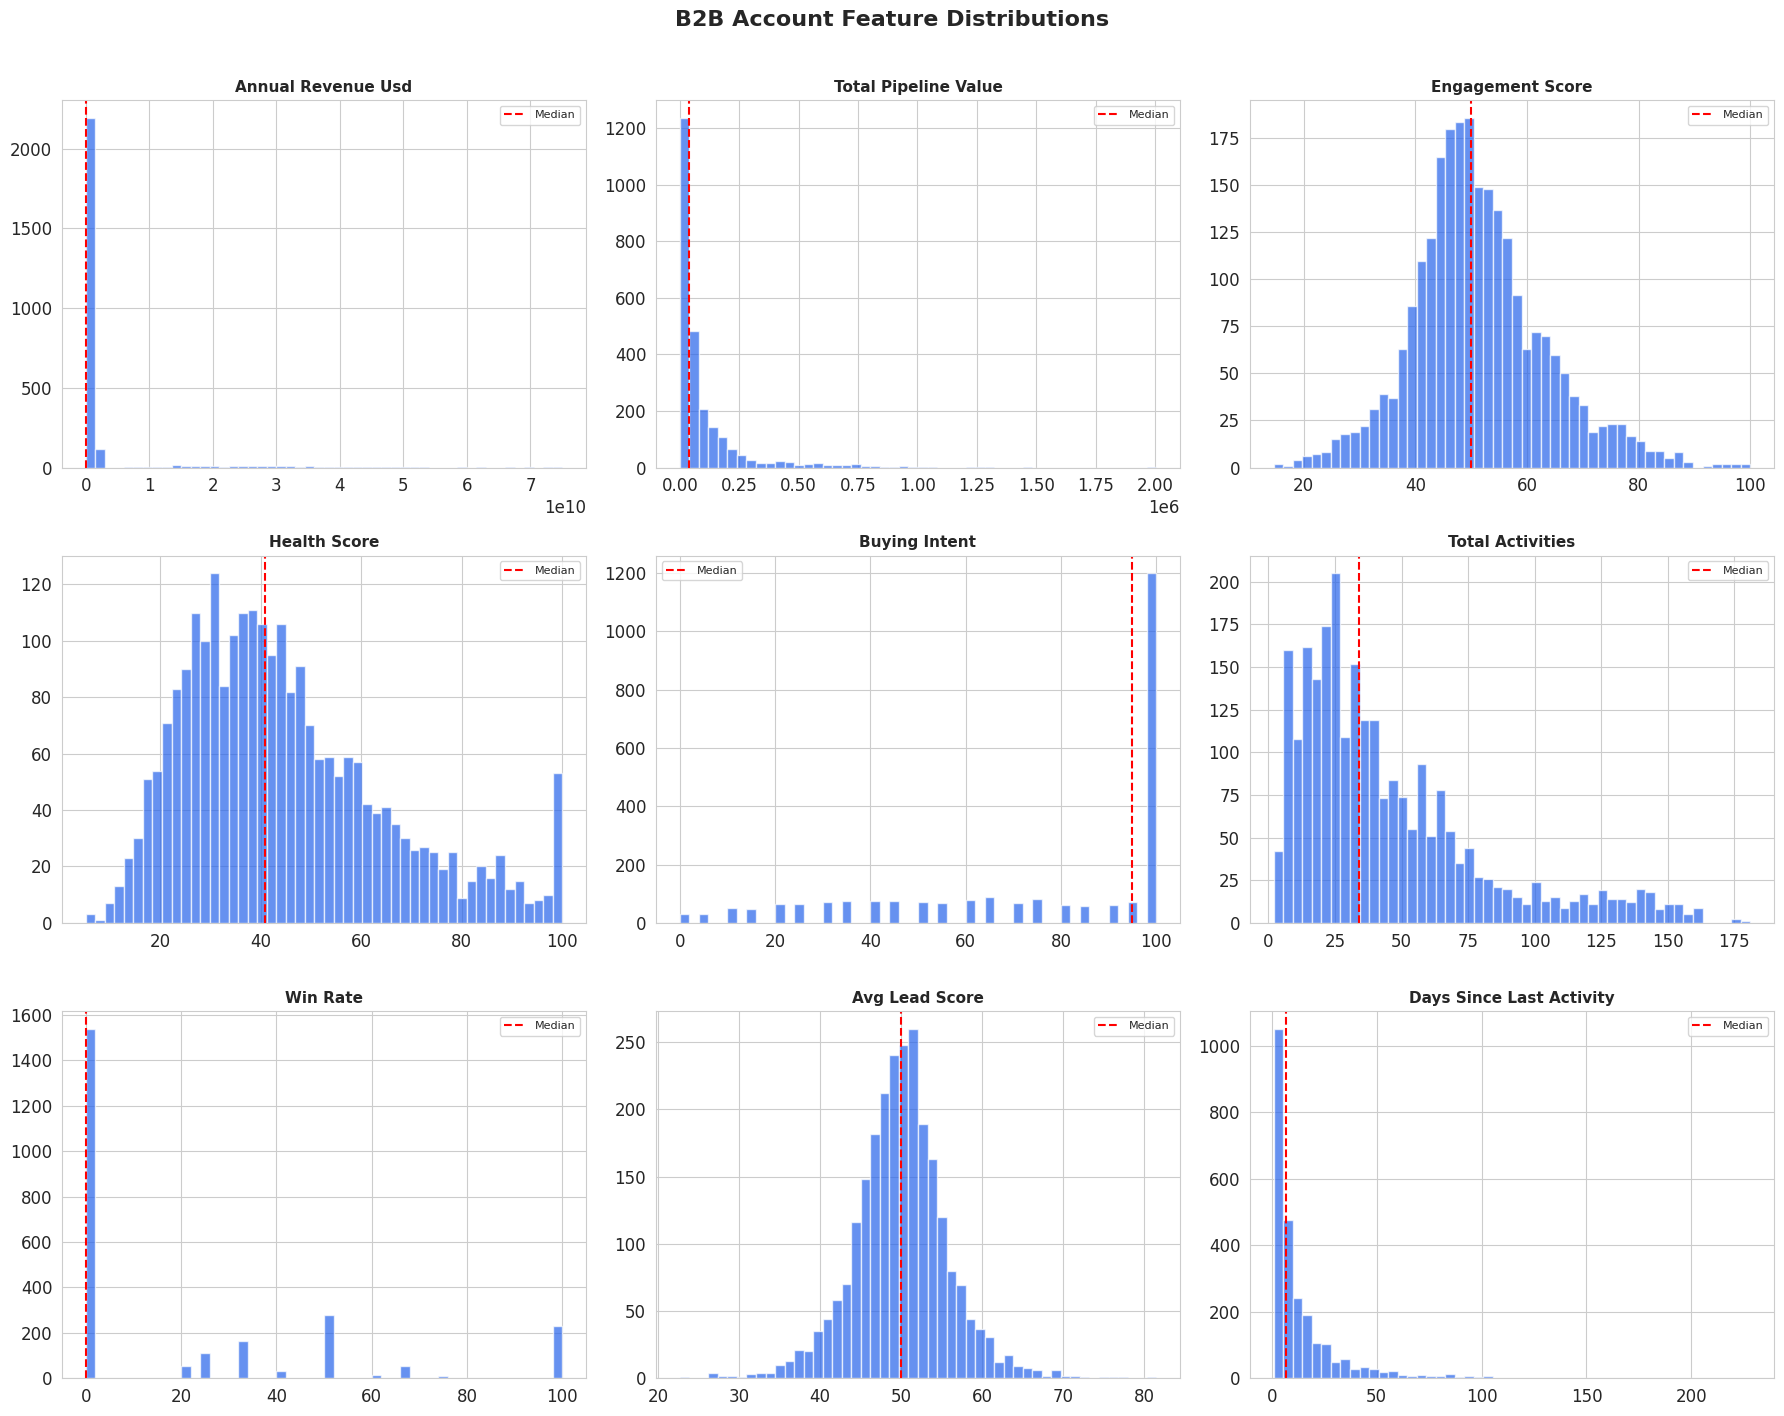

In [12]:
# ============================================================
# STEP 5A: Distribution of Key Features
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
plot_features = ['annual_revenue_usd', 'total_pipeline_value', 'engagement_score',
                 'health_score', 'buying_intent', 'total_activities',
                 'win_rate', 'avg_lead_score', 'days_since_last_activity']

for ax, feat in zip(axes.flat, plot_features):
    ax.hist(unified_df[feat], bins=50, edgecolor='white', alpha=0.7, color='#2563EB')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.axvline(unified_df[feat].median(), color='red', linestyle='--', label='Median')
    ax.legend(fontsize=8)

plt.suptitle('B2B Account Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

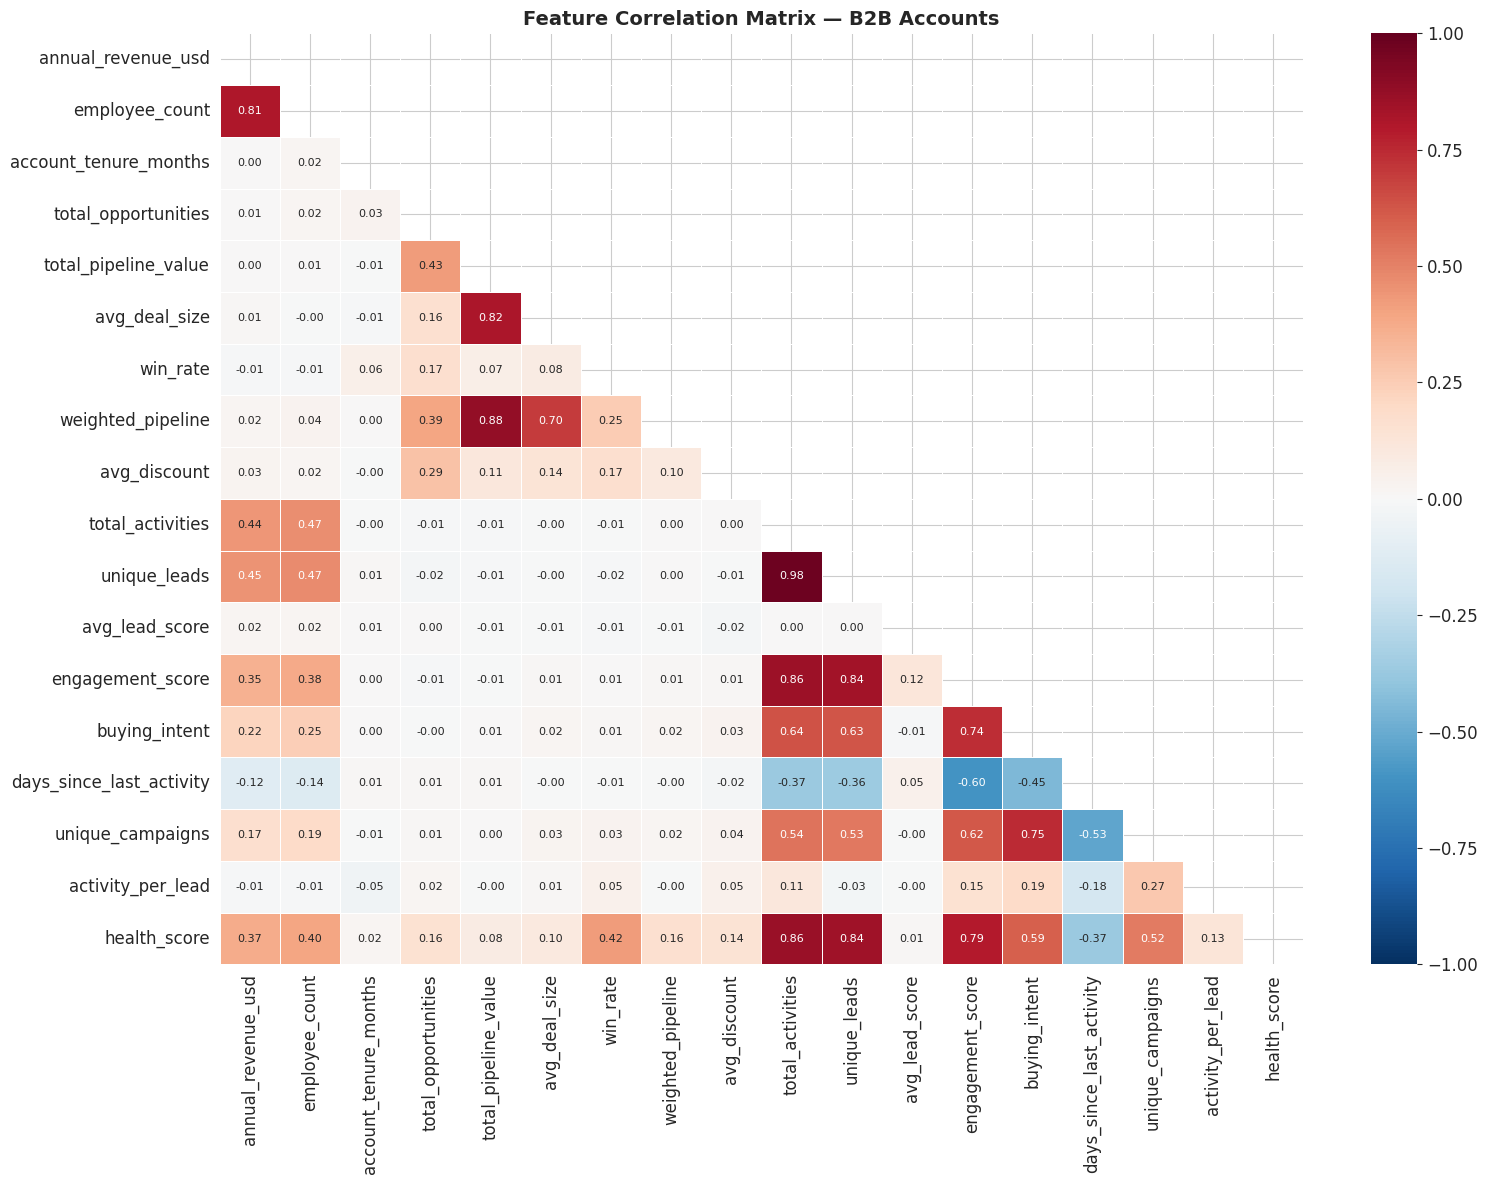

In [13]:
# ============================================================
# STEP 5B: Correlation Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(16, 12))
corr = unified_df[clustering_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix — B2B Accounts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

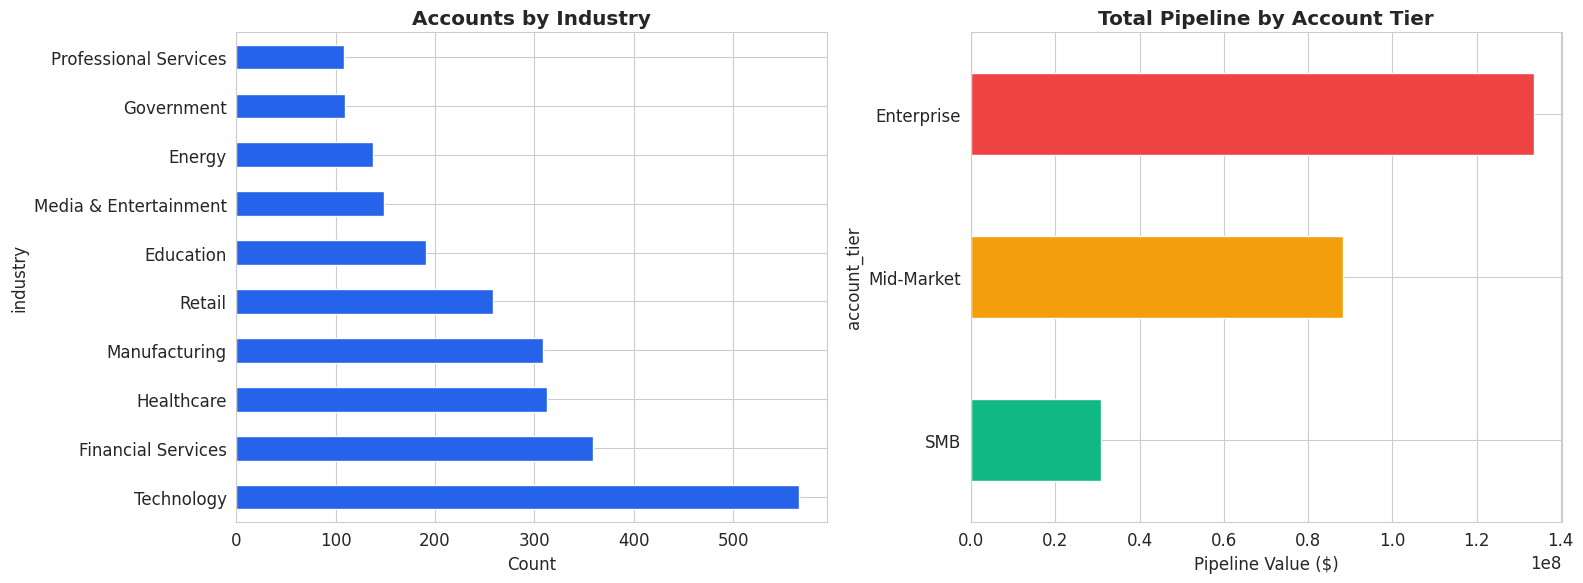

In [14]:
# ============================================================
# STEP 5C: Industry & Tier Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

unified_df['industry'].value_counts().plot.barh(ax=axes[0], color='#2563EB', edgecolor='white')
axes[0].set_title('Accounts by Industry', fontweight='bold')
axes[0].set_xlabel('Count')

tier_pipeline = unified_df.groupby('account_tier')['total_pipeline_value'].sum().sort_values()
tier_pipeline.plot.barh(ax=axes[1], color=['#10B981', '#F59E0B', '#EF4444'], edgecolor='white')
axes[1].set_title('Total Pipeline by Account Tier', fontweight='bold')
axes[1].set_xlabel('Pipeline Value ($)')

plt.tight_layout()
plt.show()

---
## Step 6 — Advanced Segmentation Techniques

### 6A: RFM Analysis (Recency, Frequency, Monetary)

In [15]:
# ============================================================
# STEP 6A: RFM Segmentation
# R = Days since last activity (lower = better)
# F = Total engagement activities
# M = Total pipeline value
# ============================================================
rfm = unified_df[['sf_account_id', 'account_name', 'days_since_last_activity',
                   'total_activities', 'total_pipeline_value']].copy()
rfm.columns = ['sf_account_id', 'account_name', 'Recency', 'Frequency', 'Monetary']

# Score 1-5 using quintiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)  # Inverted
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] * 100 + rfm['F_Score'] * 10 + rfm['M_Score']
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# B2B-specific segment labels
def b2b_rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions (Strategic Accounts)'
    elif r >= 3 and m >= 4:
        return 'High-Value Active'
    elif r >= 4 and f >= 3 and m < 3:
        return 'Engaged — Upsell Potential'
    elif r >= 4 and f < 3:
        return 'New/Recently Activated'
    elif r < 3 and f >= 3 and m >= 3:
        return 'At-Risk (Fading Champions)'
    elif r < 3 and m >= 3:
        return 'At-Risk (High Value)'
    elif r < 2 and f < 2:
        return 'Dormant / Lost'
    else:
        return 'Nurture Required'

rfm['RFM_Segment'] = rfm.apply(b2b_rfm_segment, axis=1)

print('📊 B2B RFM SEGMENT DISTRIBUTION')
seg_summary = rfm.groupby('RFM_Segment').agg(
    count=('sf_account_id', 'count'),
    avg_recency=('Recency', 'mean'),
    avg_frequency=('Frequency', 'mean'),
    avg_monetary=('Monetary', 'mean'),
).round(1)
seg_summary['pct'] = (seg_summary['count'] / seg_summary['count'].sum() * 100).round(1)
print(seg_summary.sort_values('avg_monetary', ascending=False).to_string())

📊 B2B RFM SEGMENT DISTRIBUTION
                                count  avg_recency  avg_frequency  avg_monetary   pct
RFM_Segment                                                                          
Champions (Strategic Accounts)    251          2.7           84.5      224976.8  10.0
High-Value Active                 365          5.5           36.7      218770.5  14.6
At-Risk (High Value)              371         38.8           15.7      163092.2  14.8
At-Risk (Fading Champions)        200         18.4           47.1      161716.9   8.0
New/Recently Activated            139          2.8           19.1       22949.9   5.6
Nurture Required                  739         11.8           46.3       21203.3  29.6
Dormant / Lost                    108         56.6            9.9       10999.1   4.3
Engaged — Upsell Potential        327          2.7           75.0       10625.1  13.1


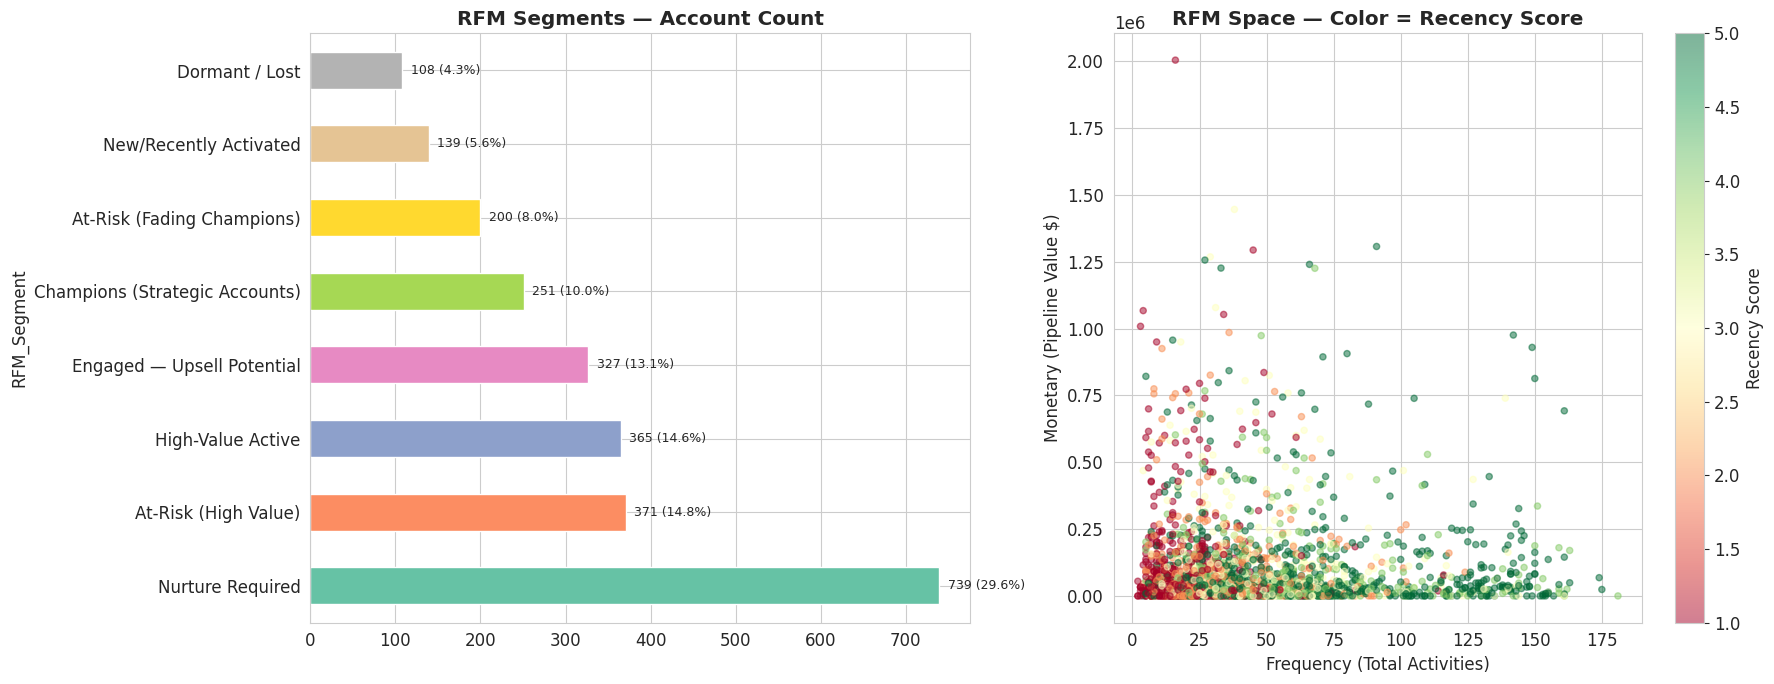

In [16]:
# RFM Segment Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Treemap-style bar chart
seg_counts = rfm['RFM_Segment'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(seg_counts)))
seg_counts.plot.barh(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('RFM Segments — Account Count', fontweight='bold')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 10, i, f'{v} ({v/len(rfm)*100:.1f}%)', va='center', fontsize=9)

# RFM Score scatter
scatter = axes[1].scatter(
    rfm['Frequency'], rfm['Monetary'],
    c=rfm['R_Score'], cmap='RdYlGn', s=20, alpha=0.5
)
axes[1].set_xlabel('Frequency (Total Activities)')
axes[1].set_ylabel('Monetary (Pipeline Value $)')
axes[1].set_title('RFM Space — Color = Recency Score', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Recency Score')

plt.tight_layout()
plt.show()

### 6B: K-Means Clustering with Optimal K Selection

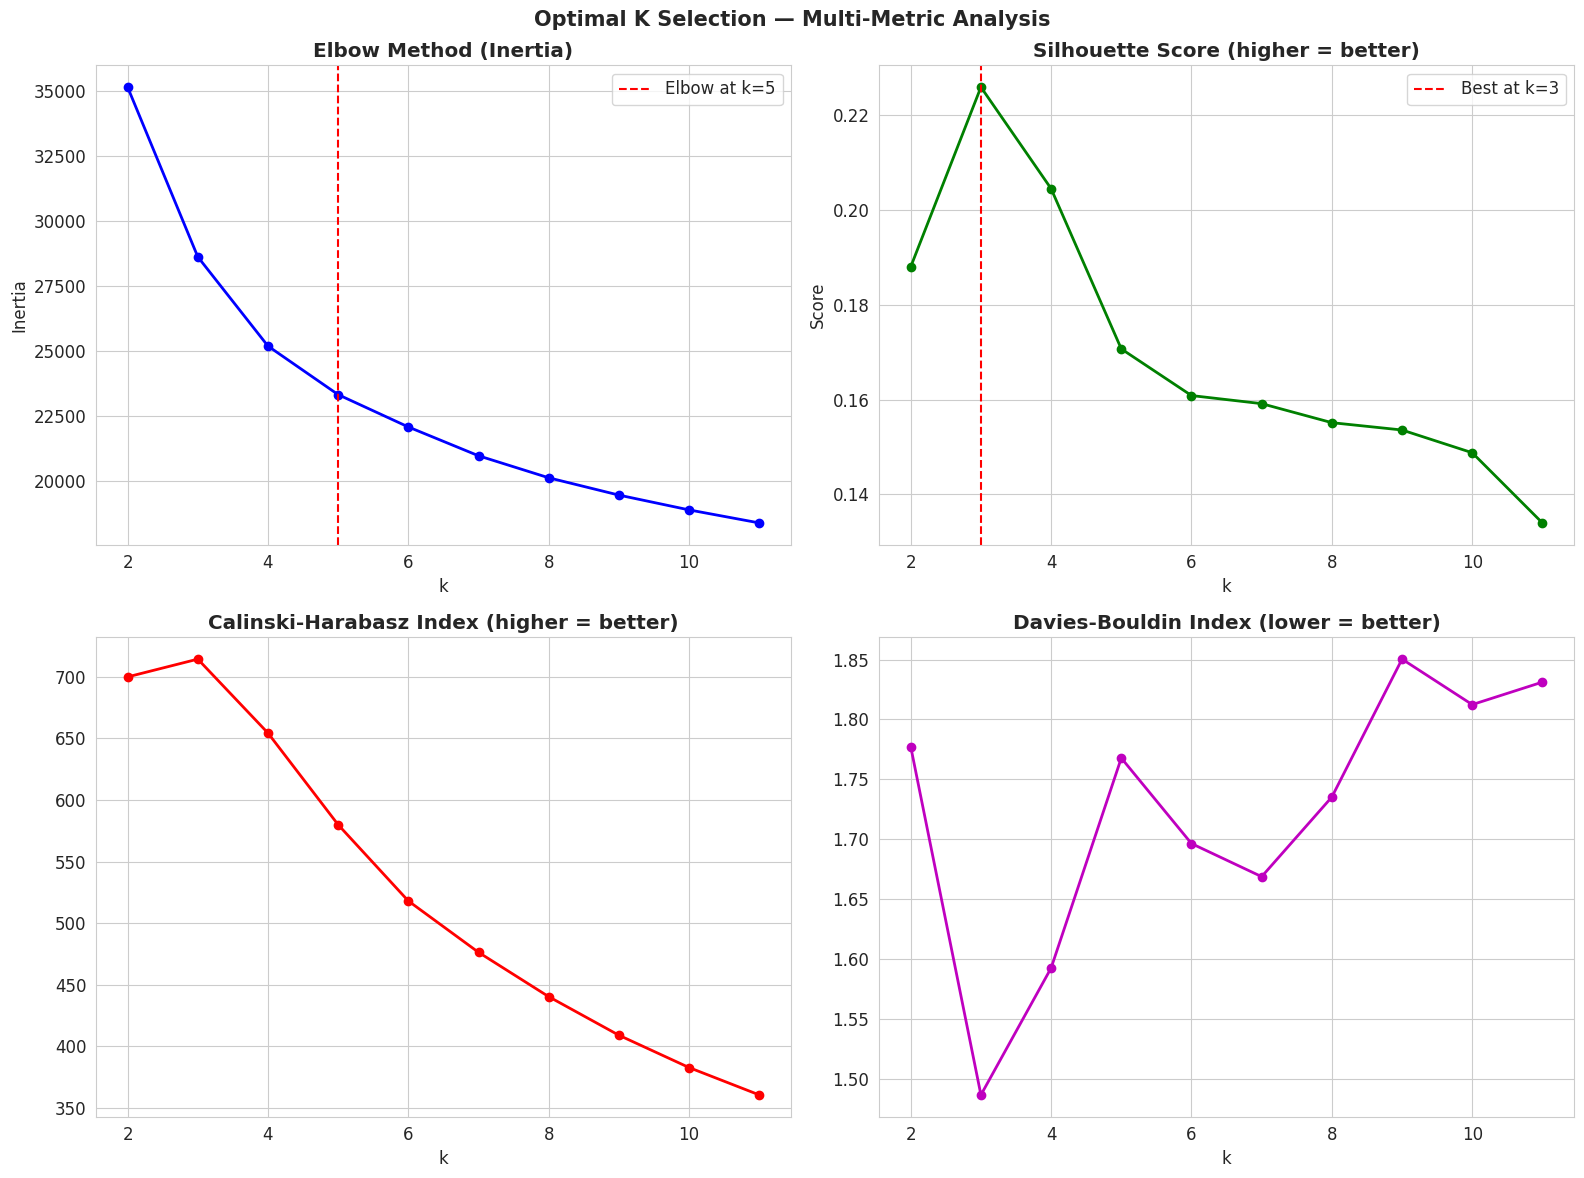


🎯 Recommended K: 5 (Elbow) | 3 (Silhouette)


In [17]:
# ============================================================
# STEP 6B: K-Means — Elbow Method + Silhouette Analysis
# ============================================================
K_range = range(2, 12)
inertias = []
silhouettes = []
calinski = []
davies = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    calinski.append(calinski_harabasz_score(X_scaled, labels))
    davies.append(davies_bouldin_score(X_scaled, labels))

# Find optimal k via elbow
kn = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
optimal_k = kn.knee if kn.knee else 5

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0,0].axvline(optimal_k, color='red', linestyle='--', label=f'Elbow at k={optimal_k}')
axes[0,0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia')
axes[0,0].legend()

axes[0,1].plot(K_range, silhouettes, 'go-', linewidth=2)
best_sil_k = list(K_range)[np.argmax(silhouettes)]
axes[0,1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best at k={best_sil_k}')
axes[0,1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Score')
axes[0,1].legend()

axes[1,0].plot(K_range, calinski, 'ro-', linewidth=2)
axes[1,0].set_title('Calinski-Harabasz Index (higher = better)', fontweight='bold')
axes[1,0].set_xlabel('k')

axes[1,1].plot(K_range, davies, 'mo-', linewidth=2)
axes[1,1].set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')
axes[1,1].set_xlabel('k')

plt.suptitle('Optimal K Selection — Multi-Metric Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n🎯 Recommended K: {optimal_k} (Elbow) | {best_sil_k} (Silhouette)')

In [18]:
# ============================================================
# STEP 6B-2: Fit Final K-Means Model
# ============================================================
FINAL_K = max(optimal_k, best_sil_k)  # Use the higher quality suggestion
if FINAL_K > 7:
    FINAL_K = 5  # Cap for interpretability

kmeans = KMeans(n_clusters=FINAL_K, init='k-means++', n_init=25, random_state=42)
unified_df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print(f'✅ K-Means fitted with K={FINAL_K}')
print(f'   Silhouette: {silhouette_score(X_scaled, unified_df["kmeans_cluster"]):.4f}')
print(f'   Inertia:    {kmeans.inertia_:,.0f}')
print(f'\n--- Cluster Sizes ---')
print(unified_df['kmeans_cluster'].value_counts().sort_index().to_string())

✅ K-Means fitted with K=5
   Silhouette: 0.1707
   Inertia:    23,320

--- Cluster Sizes ---
kmeans_cluster
0    296
1    286
2    816
3    765
4    337


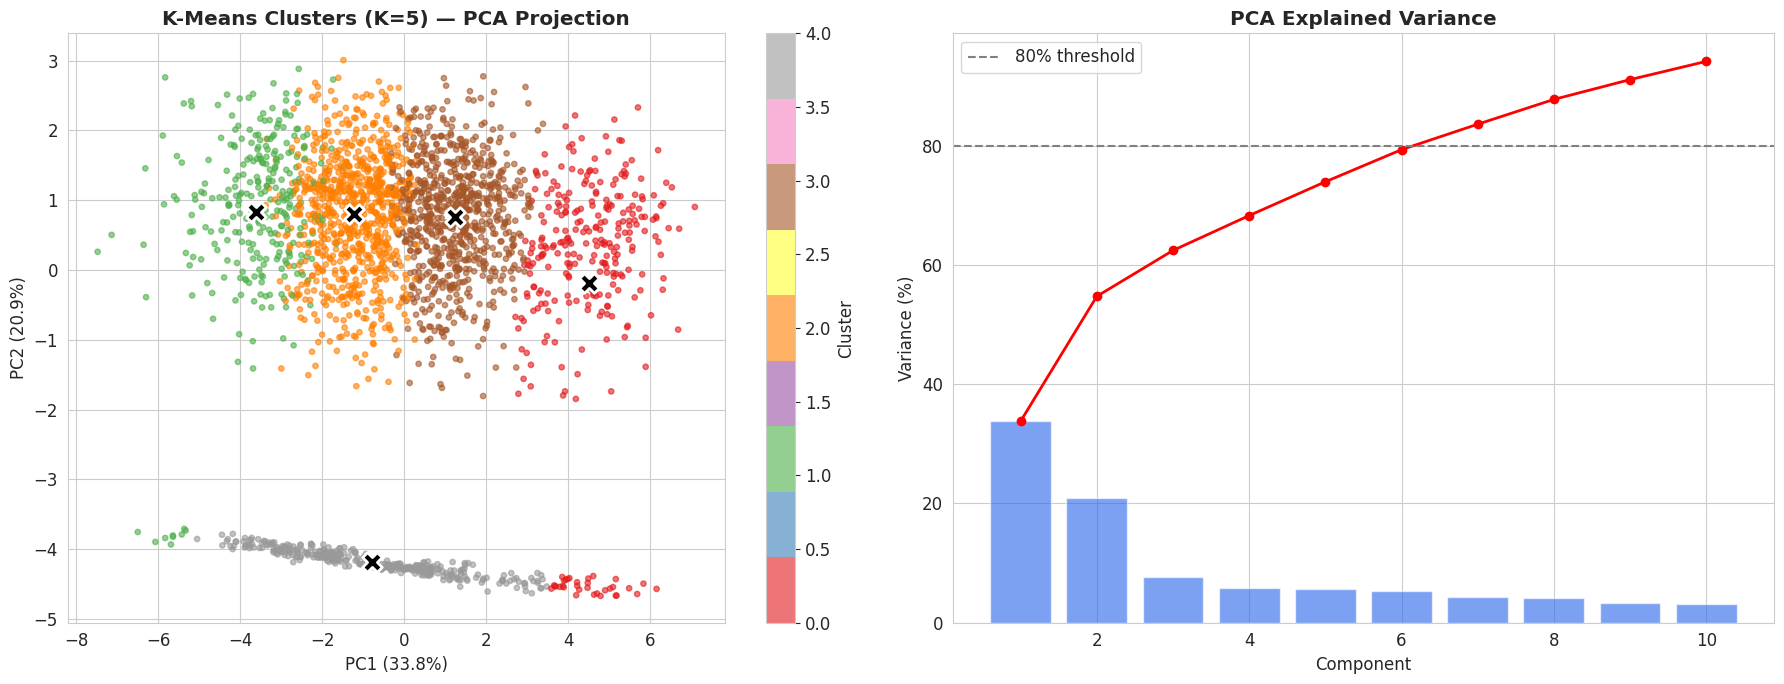

In [21]:
# ============================================================
# STEP 6B-3: PCA Visualization of K-Means Clusters
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
    c=unified_df['kmeans_cluster'], cmap='Set1', s=15, alpha=0.6)
# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=200, linewidth=2, edgecolors='white')
axes[0].set_title(f'K-Means Clusters (K={FINAL_K}) — PCA Projection', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# 3-component for variance
pca3 = PCA(n_components=min(10, len(clustering_features)), random_state=42)
pca3.fit(X_scaled)
cum_var = np.cumsum(pca3.explained_variance_ratio_) * 100
axes[1].bar(range(1, len(cum_var)+1), pca3.explained_variance_ratio_*100, alpha=0.6, color='#2563EB')
axes[1].plot(range(1, len(cum_var)+1), cum_var, 'ro-', linewidth=2)
axes[1].axhline(80, color='gray', linestyle='--', label='80% threshold')
axes[1].set_title('PCA Explained Variance', fontweight='bold')
axes[1].set_xlabel('Component'); axes[1].set_ylabel('Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6C: Hierarchical Clustering

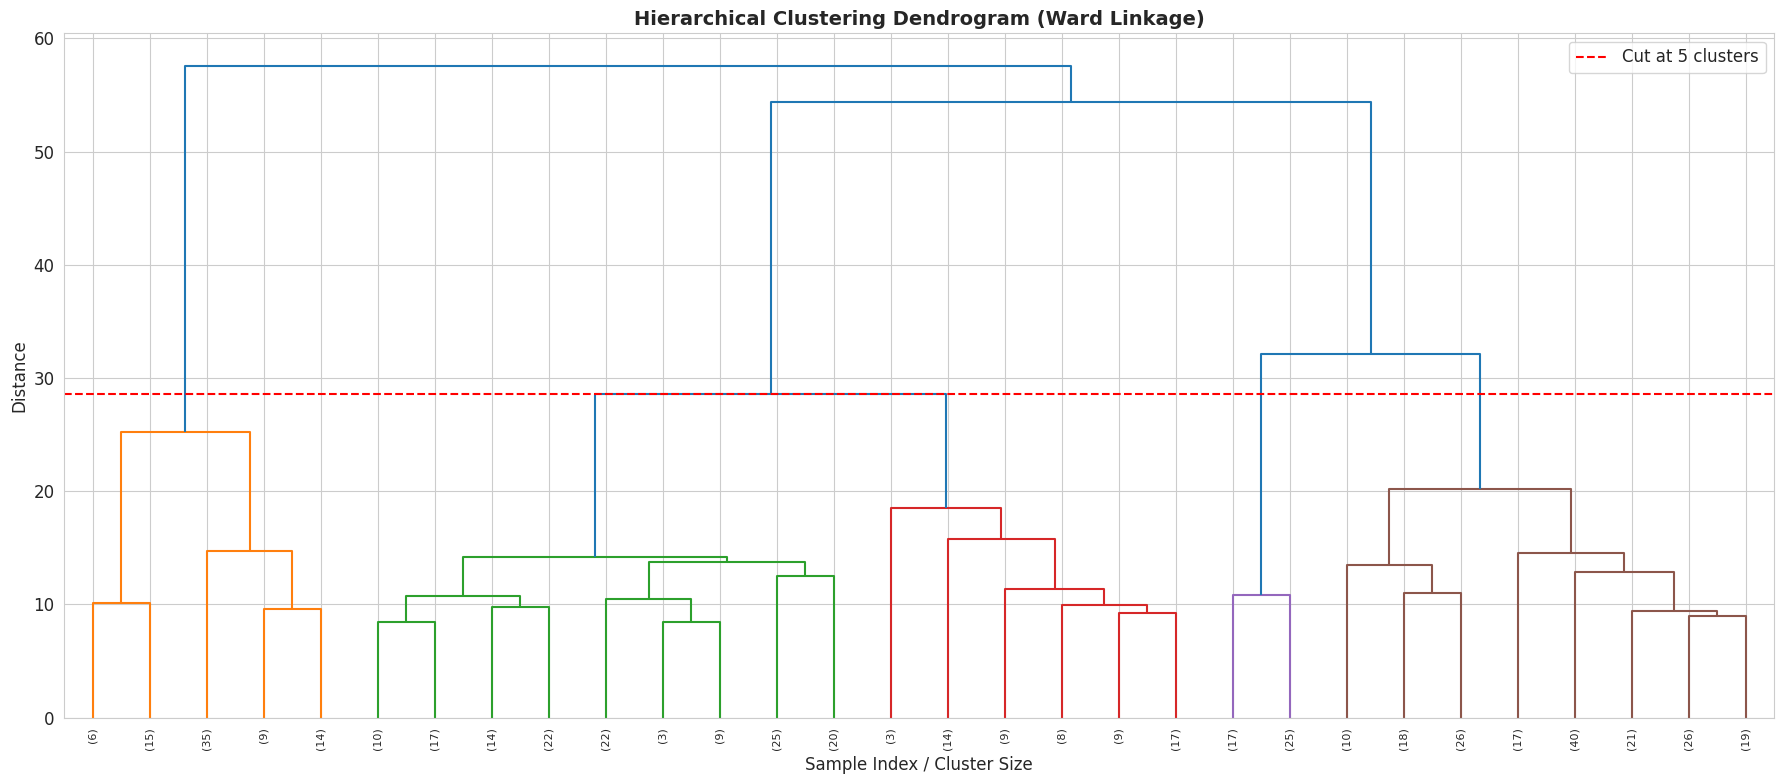


✅ Hierarchical Clustering: Silhouette = 0.1326
hc_cluster
0     379
1    1078
2     243
3     219
4     581


In [22]:
# ============================================================
# STEP 6C: Hierarchical (Agglomerative) Clustering
# ============================================================
# Use a sample for dendrogram (full dataset too large)
sample_idx = np.random.choice(len(X_scaled), size=min(500, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

linkage_matrix = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(18, 8))
dendrogram(
    linkage_matrix, truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=8, ax=ax,
    color_threshold=linkage_matrix[-FINAL_K+1, 2]  # Cut at same K as K-Means
)
ax.axhline(linkage_matrix[-FINAL_K+1, 2], color='red', linestyle='--',
           label=f'Cut at {FINAL_K} clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sample Index / Cluster Size')
ax.set_ylabel('Distance')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Fit on full data
hc = AgglomerativeClustering(n_clusters=FINAL_K, linkage='ward')
unified_df['hc_cluster'] = hc.fit_predict(X_scaled)

print(f'\n✅ Hierarchical Clustering: Silhouette = {silhouette_score(X_scaled, unified_df["hc_cluster"]):.4f}')
print(unified_df['hc_cluster'].value_counts().sort_index().to_string())

### 6D: DBSCAN — Density-Based Anomaly Detection

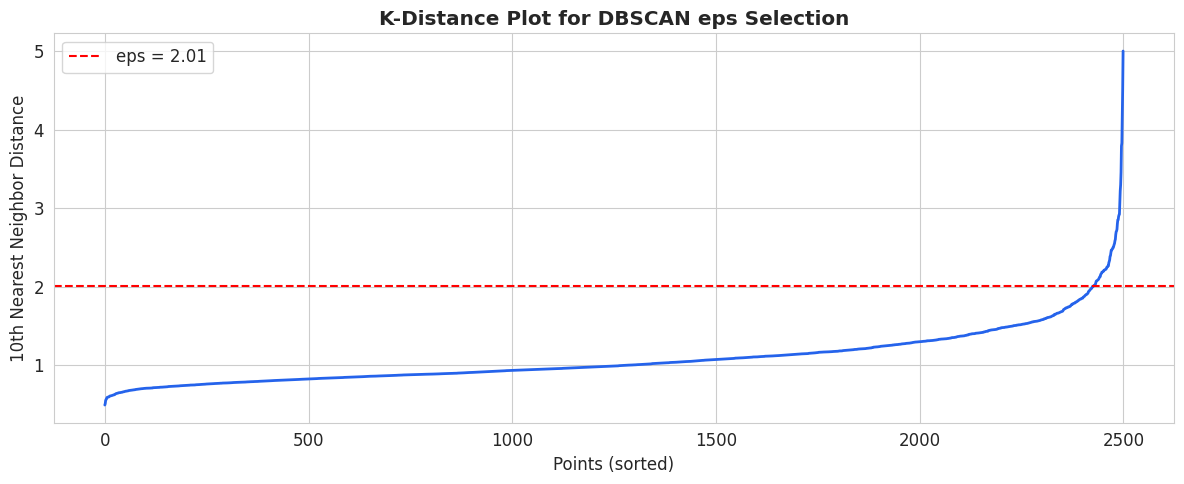


✅ DBSCAN Results:
   Clusters found: 2
   Noise points (anomalies): 17 (0.7%)
   These noise points represent unusual accounts that don't fit any pattern.


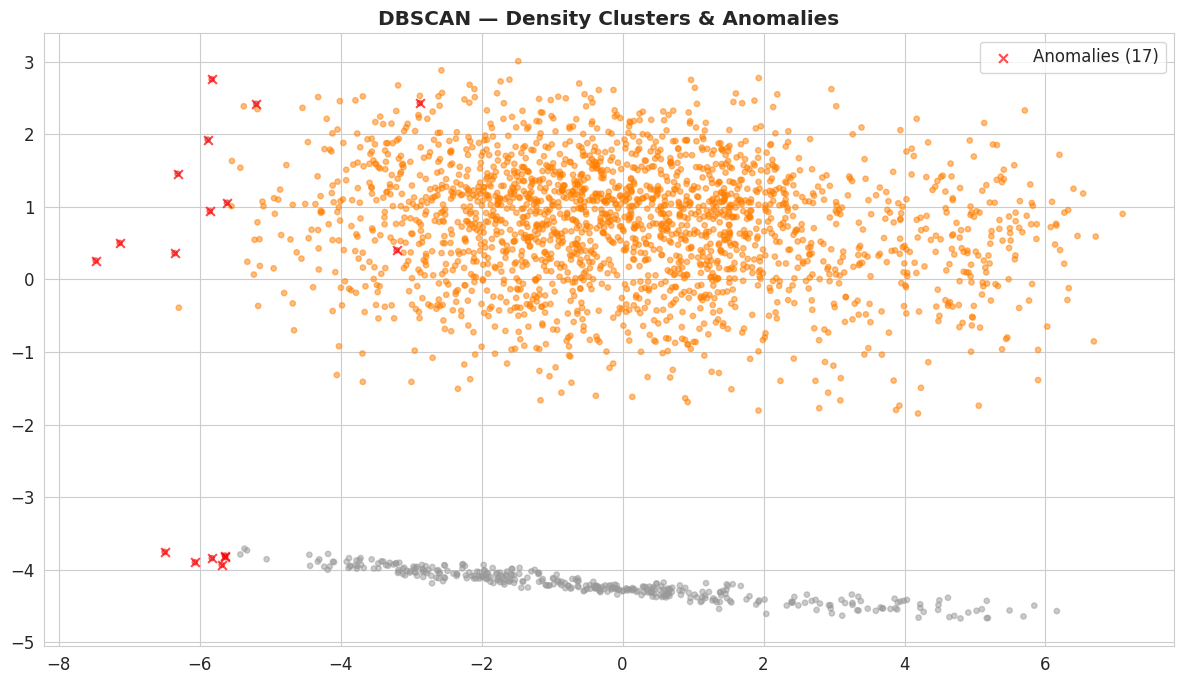

In [23]:
# ============================================================
# STEP 6D: DBSCAN for Outlier / Anomaly Detection
# ============================================================
# Use PCA-reduced data for DBSCAN (curse of dimensionality)
pca_5 = PCA(n_components=5, random_state=42)
X_pca5 = pca_5.fit_transform(X_scaled)

# Optimize eps using nearest-neighbor distance plot
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_pca5)
distances, _ = nn.kneighbors(X_pca5)
sorted_dists = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sorted_dists, color='#2563EB', linewidth=2)
# Find the knee
eps_knee = KneeLocator(range(len(sorted_dists)), sorted_dists, curve='convex', direction='increasing')
best_eps = sorted_dists[eps_knee.knee] if eps_knee.knee else 3.0
ax.axhline(best_eps, color='red', linestyle='--', label=f'eps = {best_eps:.2f}')
ax.set_title('K-Distance Plot for DBSCAN eps Selection', fontweight='bold')
ax.set_xlabel('Points (sorted)'); ax.set_ylabel('10th Nearest Neighbor Distance')
ax.legend()
plt.tight_layout()
plt.show()

# Fit DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=10)
unified_df['dbscan_cluster'] = dbscan.fit_predict(X_pca5)

n_clusters_db = len(set(unified_df['dbscan_cluster'])) - (1 if -1 in unified_df['dbscan_cluster'].values else 0)
n_noise = (unified_df['dbscan_cluster'] == -1).sum()

print(f'\n✅ DBSCAN Results:')
print(f'   Clusters found: {n_clusters_db}')
print(f'   Noise points (anomalies): {n_noise} ({n_noise/len(unified_df)*100:.1f}%)')
print(f'   These noise points represent unusual accounts that don\'t fit any pattern.')

# Visualize
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
    c=unified_df['dbscan_cluster'], cmap='Set1', s=15, alpha=0.5)
noise_mask = unified_df['dbscan_cluster'] == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    c='red', marker='x', s=40, label=f'Anomalies ({n_noise})', alpha=0.7)
ax.set_title('DBSCAN — Density Clusters & Anomalies', fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 6E: Gaussian Mixture Model (GMM)

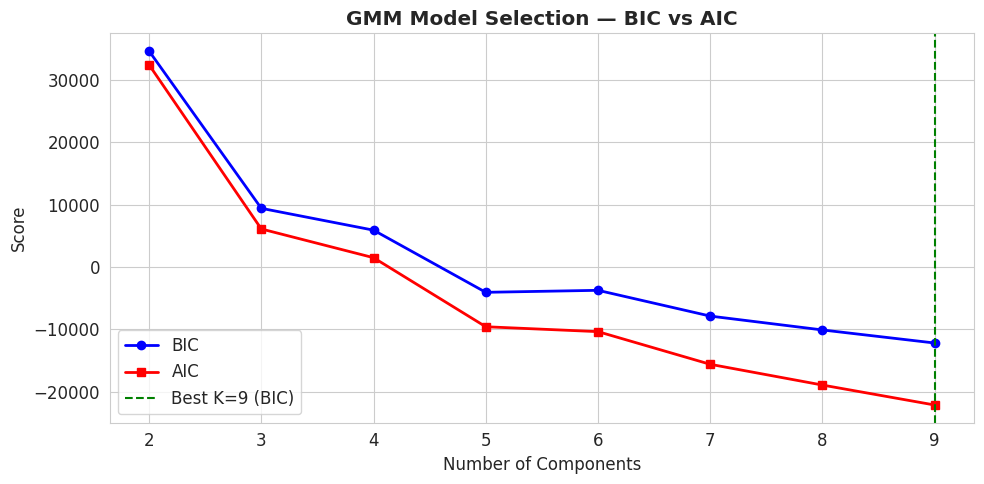


✅ GMM Results (K=5):
   Avg cluster confidence: 0.9978
   Low-confidence accounts (<0.5): 0
   These accounts sit at cluster boundaries — potential transition accounts.


In [24]:
# ============================================================
# STEP 6E: Gaussian Mixture Model — Soft Clustering
# ============================================================
# GMM gives probability of belonging to each cluster (soft assignment)
bic_scores = []
aic_scores = []
for k in range(2, 10):
    gmm_temp = GaussianMixture(n_components=k, covariance_type='full',
                               random_state=42, n_init=5, max_iter=300)
    gmm_temp.fit(X_scaled)
    bic_scores.append(gmm_temp.bic(X_scaled))
    aic_scores.append(gmm_temp.aic(X_scaled))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(2, 10), bic_scores, 'bo-', label='BIC', linewidth=2)
ax.plot(range(2, 10), aic_scores, 'rs-', label='AIC', linewidth=2)
best_gmm_k = range(2, 10)[np.argmin(bic_scores)]
ax.axvline(best_gmm_k, color='green', linestyle='--', label=f'Best K={best_gmm_k} (BIC)')
ax.set_title('GMM Model Selection — BIC vs AIC', fontweight='bold')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

# Fit final GMM
gmm = GaussianMixture(n_components=FINAL_K, covariance_type='full',
                       random_state=42, n_init=10)
unified_df['gmm_cluster'] = gmm.fit_predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

# Store max probability (confidence)
unified_df['gmm_confidence'] = gmm_probs.max(axis=1).round(4)

print(f'\n✅ GMM Results (K={FINAL_K}):')
print(f'   Avg cluster confidence: {unified_df["gmm_confidence"].mean():.4f}')
print(f'   Low-confidence accounts (<0.5): {(unified_df["gmm_confidence"] < 0.5).sum()}')
print(f'   These accounts sit at cluster boundaries — potential transition accounts.')

---
## Step 7 — Model Comparison & Consensus Segmentation

In [25]:
# ============================================================
# STEP 7: Compare Clustering Methods
# ============================================================
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

methods = ['kmeans_cluster', 'hc_cluster', 'gmm_cluster']
method_names = ['K-Means', 'Hierarchical', 'GMM']

print('📊 CLUSTERING METHOD COMPARISON')
print('=' * 60)

# Quality metrics
for name, col in zip(method_names, methods):
    sil = silhouette_score(X_scaled, unified_df[col])
    ch = calinski_harabasz_score(X_scaled, unified_df[col])
    db = davies_bouldin_score(X_scaled, unified_df[col])
    print(f'  {name:15s} | Silhouette: {sil:.4f} | Calinski-H: {ch:,.0f} | Davies-B: {db:.4f}')

# Agreement between methods
print(f'\n--- Inter-Method Agreement ---')
for i in range(len(methods)):
    for j in range(i+1, len(methods)):
        ari = adjusted_rand_score(unified_df[methods[i]], unified_df[methods[j]])
        nmi = normalized_mutual_info_score(unified_df[methods[i]], unified_df[methods[j]])
        print(f'  {method_names[i]} vs {method_names[j]}: ARI={ari:.4f}, NMI={nmi:.4f}')

📊 CLUSTERING METHOD COMPARISON
  K-Means         | Silhouette: 0.1707 | Calinski-H: 580 | Davies-B: 1.7679
  Hierarchical    | Silhouette: 0.1326 | Calinski-H: 496 | Davies-B: 1.8301
  GMM             | Silhouette: 0.1322 | Calinski-H: 425 | Davies-B: 2.1778

--- Inter-Method Agreement ---
  K-Means vs Hierarchical: ARI=0.5807, NMI=0.6634
  K-Means vs GMM: ARI=0.3826, NMI=0.5030
  Hierarchical vs GMM: ARI=0.3375, NMI=0.5192


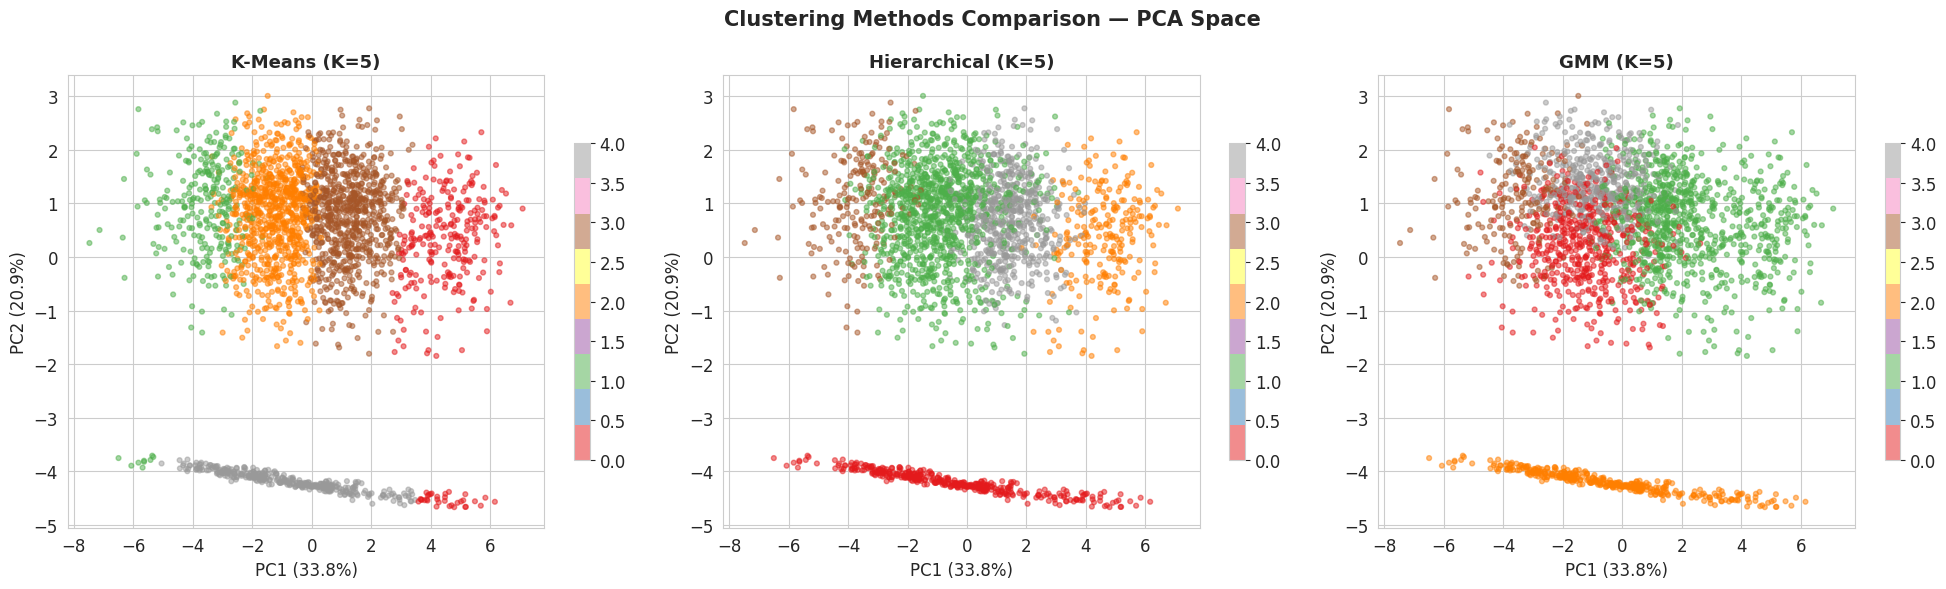

In [26]:
# ============================================================
# STEP 7B: Multi-Method Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, name in zip(axes, methods, method_names):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
        c=unified_df[col], cmap='Set1', s=12, alpha=0.5)
    ax.set_title(f'{name} (K={FINAL_K})', fontweight='bold', fontsize=13)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.colorbar(scatter, ax=ax, shrink=0.7)

plt.suptitle('Clustering Methods Comparison — PCA Space', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 8 — Segment Profiling & Business Interpretation

In [27]:
# ============================================================
# STEP 8A: Deep Segment Profiling (Using K-Means as primary)
# ============================================================
profile_cols = [
    'annual_revenue_usd', 'employee_count', 'total_opportunities',
    'total_pipeline_value', 'avg_deal_size', 'win_rate',
    'total_activities', 'engagement_score', 'buying_intent',
    'health_score', 'days_since_last_activity', 'unique_leads',
    'avg_lead_score', 'avg_discount'
]

segment_profile = unified_df.groupby('kmeans_cluster')[profile_cols].agg(['mean', 'median']).round(2)
segment_profile.columns = [f'{col}_{stat}' for col, stat in segment_profile.columns]

# Add counts
segment_profile['account_count'] = unified_df.groupby('kmeans_cluster').size()
segment_profile['pct_of_total'] = (segment_profile['account_count'] / len(unified_df) * 100).round(1)

print('📊 SEGMENT PROFILES (K-Means)')
print(segment_profile[['account_count', 'pct_of_total',
    'annual_revenue_usd_mean', 'total_pipeline_value_mean',
    'engagement_score_mean', 'health_score_mean',
    'buying_intent_mean', 'days_since_last_activity_mean']].to_string())

📊 SEGMENT PROFILES (K-Means)
                account_count  pct_of_total  annual_revenue_usd_mean  total_pipeline_value_mean  engagement_score_mean  health_score_mean  buying_intent_mean  days_since_last_activity_mean
kmeans_cluster                                                                                                                                                                              
0                         296          11.8             1.414120e+10                   98530.21                  71.73              82.39              100.00                           3.77
1                         286          11.4             3.129770e+07                  124082.83                  33.88              26.28               24.39                          50.64
2                         816          32.6             5.167227e+07                  111800.90                  46.43              36.09               62.41                          13.50
3                         

In [28]:
# ============================================================
# STEP 8B: Assign Business-Meaningful Segment Names
# ============================================================
# Rank clusters by health_score to assign names
cluster_ranks = unified_df.groupby('kmeans_cluster')['health_score'].mean().sort_values(ascending=False)
rank_order = cluster_ranks.index.tolist()

segment_names = {
    rank_order[0]: '🏆 Tier 1 — Strategic Champions',
    rank_order[1]: '⭐ Tier 2 — Growth Accounts',
    rank_order[2]: '🔄 Tier 3 — Developing Pipeline',
}
# Handle variable K
if len(rank_order) > 3:
    segment_names[rank_order[3]] = '⚠️ Tier 4 — At-Risk / Re-engage'
if len(rank_order) > 4:
    segment_names[rank_order[4]] = '❄️ Tier 5 — Dormant / Low Priority'
for i in range(5, len(rank_order)):
    segment_names[rank_order[i]] = f'📋 Tier {i+1} — Review Needed'

unified_df['segment_name'] = unified_df['kmeans_cluster'].map(segment_names)

print('\n🏷️ FINAL B2B SEGMENT ASSIGNMENT')
for cluster_id, name in sorted(segment_names.items()):
    n = (unified_df['kmeans_cluster'] == cluster_id).sum()
    avg_pipeline = unified_df.loc[unified_df['kmeans_cluster'] == cluster_id, 'total_pipeline_value'].mean()
    avg_health = unified_df.loc[unified_df['kmeans_cluster'] == cluster_id, 'health_score'].mean()
    print(f'  {name}: {n} accounts | Avg Pipeline: ${avg_pipeline:,.0f} | Health: {avg_health:.1f}')


🏷️ FINAL B2B SEGMENT ASSIGNMENT
  🏆 Tier 1 — Strategic Champions: 296 accounts | Avg Pipeline: $98,530 | Health: 82.4
  ❄️ Tier 5 — Dormant / Low Priority: 286 accounts | Avg Pipeline: $124,083 | Health: 26.3
  🔄 Tier 3 — Developing Pipeline: 816 accounts | Avg Pipeline: $111,801 | Health: 36.1
  ⭐ Tier 2 — Growth Accounts: 765 accounts | Avg Pipeline: $126,550 | Health: 52.6
  ⚠️ Tier 4 — At-Risk / Re-engage: 337 accounts | Avg Pipeline: $0 | Health: 29.5


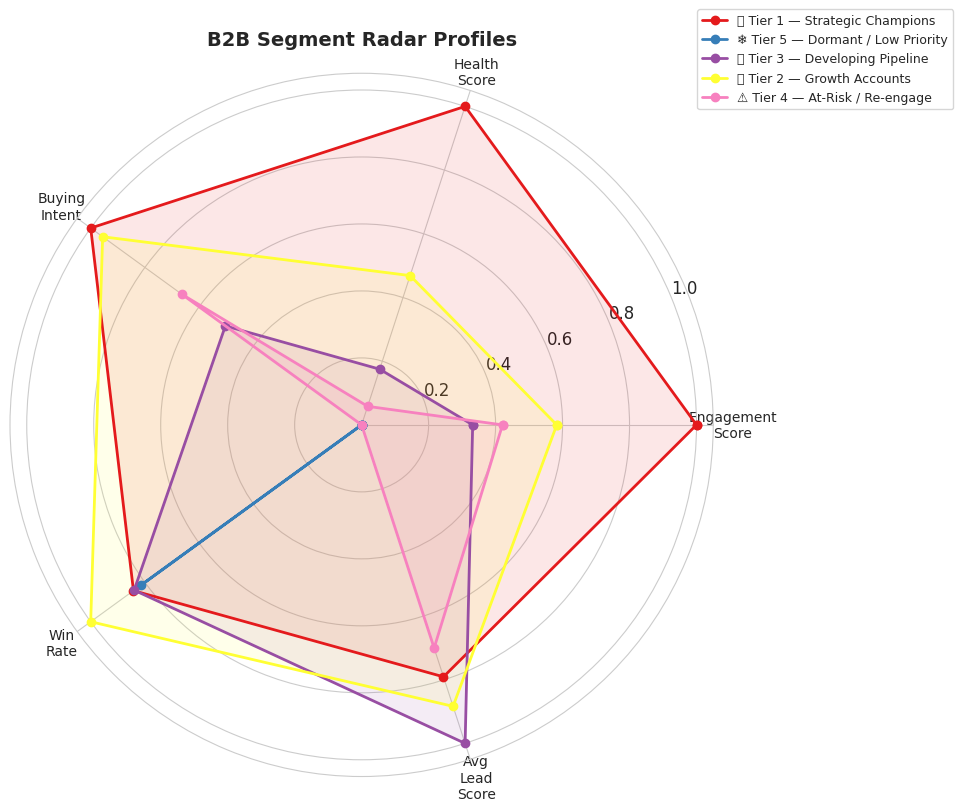

In [29]:
# ============================================================
# STEP 8C: Radar Charts for Segment Comparison
# ============================================================
radar_features = ['engagement_score', 'health_score', 'buying_intent',
                  'win_rate', 'avg_lead_score']

# Normalize to 0-1 for radar
radar_data = unified_df.groupby('kmeans_cluster')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = plt.cm.Set1(np.linspace(0, 0.8, FINAL_K))

for idx, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[idx],
            label=segment_names.get(cluster_id, f'Cluster {cluster_id}'))
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n').title() for f in radar_features], fontsize=10)
ax.set_title('B2B Segment Radar Profiles', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 8D: Segment × Industry Heatmap
# ============================================================
cross_tab = pd.crosstab(unified_df['segment_name'], unified_df['industry'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Segment × Industry Distribution (%)', fontweight='bold', fontsize=13)
ax.set_ylabel('Segment')
plt.tight_layout()
plt.show()

---
## Step 9 — Actionable Recommendations & Export

In [30]:
# ============================================================
# STEP 9A: Strategic Recommendations per Segment
# ============================================================
recommendations = {
    '🏆 Tier 1 — Strategic Champions': {
        'Marketing': 'ABM campaigns, executive events, custom content, case study partnerships',
        'Sales': 'Quarterly business reviews, expansion plays, multi-year renewals',
        'CS': 'Dedicated CSM, proactive health checks, beta program access',
        'Budget_Allocation': '35-40% of marketing budget'
    },
    '⭐ Tier 2 — Growth Accounts': {
        'Marketing': 'Targeted nurture sequences, webinar invitations, ROI calculators',
        'Sales': 'Cross-sell adjacent products, increase contract value, stakeholder mapping',
        'CS': 'Monthly check-ins, usage optimization workshops',
        'Budget_Allocation': '25-30% of marketing budget'
    },
    '🔄 Tier 3 — Developing Pipeline': {
        'Marketing': 'Educational content, drip campaigns, product demos',
        'Sales': 'Discovery calls, competitive positioning, proof of value',
        'CS': 'Onboarding support, quick-win identification',
        'Budget_Allocation': '15-20% of marketing budget'
    },
    '⚠️ Tier 4 — At-Risk / Re-engage': {
        'Marketing': 'Re-engagement campaigns, win-back offers, competitive displacement',
        'Sales': 'Save calls, executive escalation, custom pricing review',
        'CS': 'Root cause analysis, service recovery protocol',
        'Budget_Allocation': '10-15% of marketing budget'
    },
    '❄️ Tier 5 — Dormant / Low Priority': {
        'Marketing': 'Automated low-touch nurture, newsletter only, annual check-in',
        'Sales': 'Deprioritize, monitor for trigger events (funding, leadership change)',
        'CS': 'Self-serve resources, community access',
        'Budget_Allocation': '5-10% of marketing budget'
    }
}

print('🎯 STRATEGIC PLAYBOOK BY SEGMENT')
print('=' * 70)
for segment, actions in recommendations.items():
    if segment in unified_df['segment_name'].values:
        count = (unified_df['segment_name'] == segment).sum()
        print(f'\n{segment} ({count} accounts)')
        print('-' * 50)
        for team, action in actions.items():
            print(f'  {team:20s}: {action}')

🎯 STRATEGIC PLAYBOOK BY SEGMENT

🏆 Tier 1 — Strategic Champions (296 accounts)
--------------------------------------------------
  Marketing           : ABM campaigns, executive events, custom content, case study partnerships
  Sales               : Quarterly business reviews, expansion plays, multi-year renewals
  CS                  : Dedicated CSM, proactive health checks, beta program access
  Budget_Allocation   : 35-40% of marketing budget

⭐ Tier 2 — Growth Accounts (765 accounts)
--------------------------------------------------
  Marketing           : Targeted nurture sequences, webinar invitations, ROI calculators
  Sales               : Cross-sell adjacent products, increase contract value, stakeholder mapping
  CS                  : Monthly check-ins, usage optimization workshops
  Budget_Allocation   : 25-30% of marketing budget

🔄 Tier 3 — Developing Pipeline (816 accounts)
--------------------------------------------------
  Marketing           : Educational content, d

In [31]:
# ============================================================
# STEP 9B: Export Segmented Data
# ============================================================
export_cols = [
    'sf_account_id', 'account_name', 'industry', 'company_size', 'region',
    'account_tier', 'annual_revenue_usd', 'employee_count',
    'total_pipeline_value', 'win_rate', 'engagement_score',
    'health_score', 'buying_intent', 'days_since_last_activity',
    'kmeans_cluster', 'segment_name', 'gmm_confidence',
    'dbscan_cluster'
]

# Add RFM segment
unified_df = unified_df.merge(
    rfm[['sf_account_id', 'RFM_Segment', 'RFM_Total']],
    on='sf_account_id', how='left'
)
export_cols += ['RFM_Segment', 'RFM_Total']

export_df = unified_df[export_cols].copy()
export_df.to_csv('b2b_segmented_accounts.csv', index=False)

print(f'✅ Exported {len(export_df):,} accounts to b2b_segmented_accounts.csv')
print(f'   Columns: {len(export_cols)}')
print(f'\n--- Final Segment Summary ---')
final_summary = unified_df.groupby('segment_name').agg(
    accounts=('sf_account_id', 'count'),
    total_pipeline=('total_pipeline_value', 'sum'),
    avg_health=('health_score', 'mean'),
    avg_engagement=('engagement_score', 'mean'),
).round(1)
final_summary['total_pipeline_pct'] = (
    final_summary['total_pipeline'] / final_summary['total_pipeline'].sum() * 100
).round(1)
print(final_summary.sort_values('avg_health', ascending=False).to_string())

✅ Exported 2,500 accounts to b2b_segmented_accounts.csv
   Columns: 20

--- Final Segment Summary ---
                                    accounts  total_pipeline  avg_health  avg_engagement  total_pipeline_pct
segment_name                                                                                                
🏆 Tier 1 — Strategic Champions           296      29164941.3        82.4            71.7                11.5
⭐ Tier 2 — Growth Accounts               765      96810392.0        52.6            55.9                38.3
🔄 Tier 3 — Developing Pipeline           816      91229538.3        36.1            46.4                36.1
⚠️ Tier 4 — At-Risk / Re-engage          337             0.0        29.5            49.8                 0.0
❄️ Tier 5 — Dormant / Low Priority       286      35487689.7        26.3            33.9                14.0


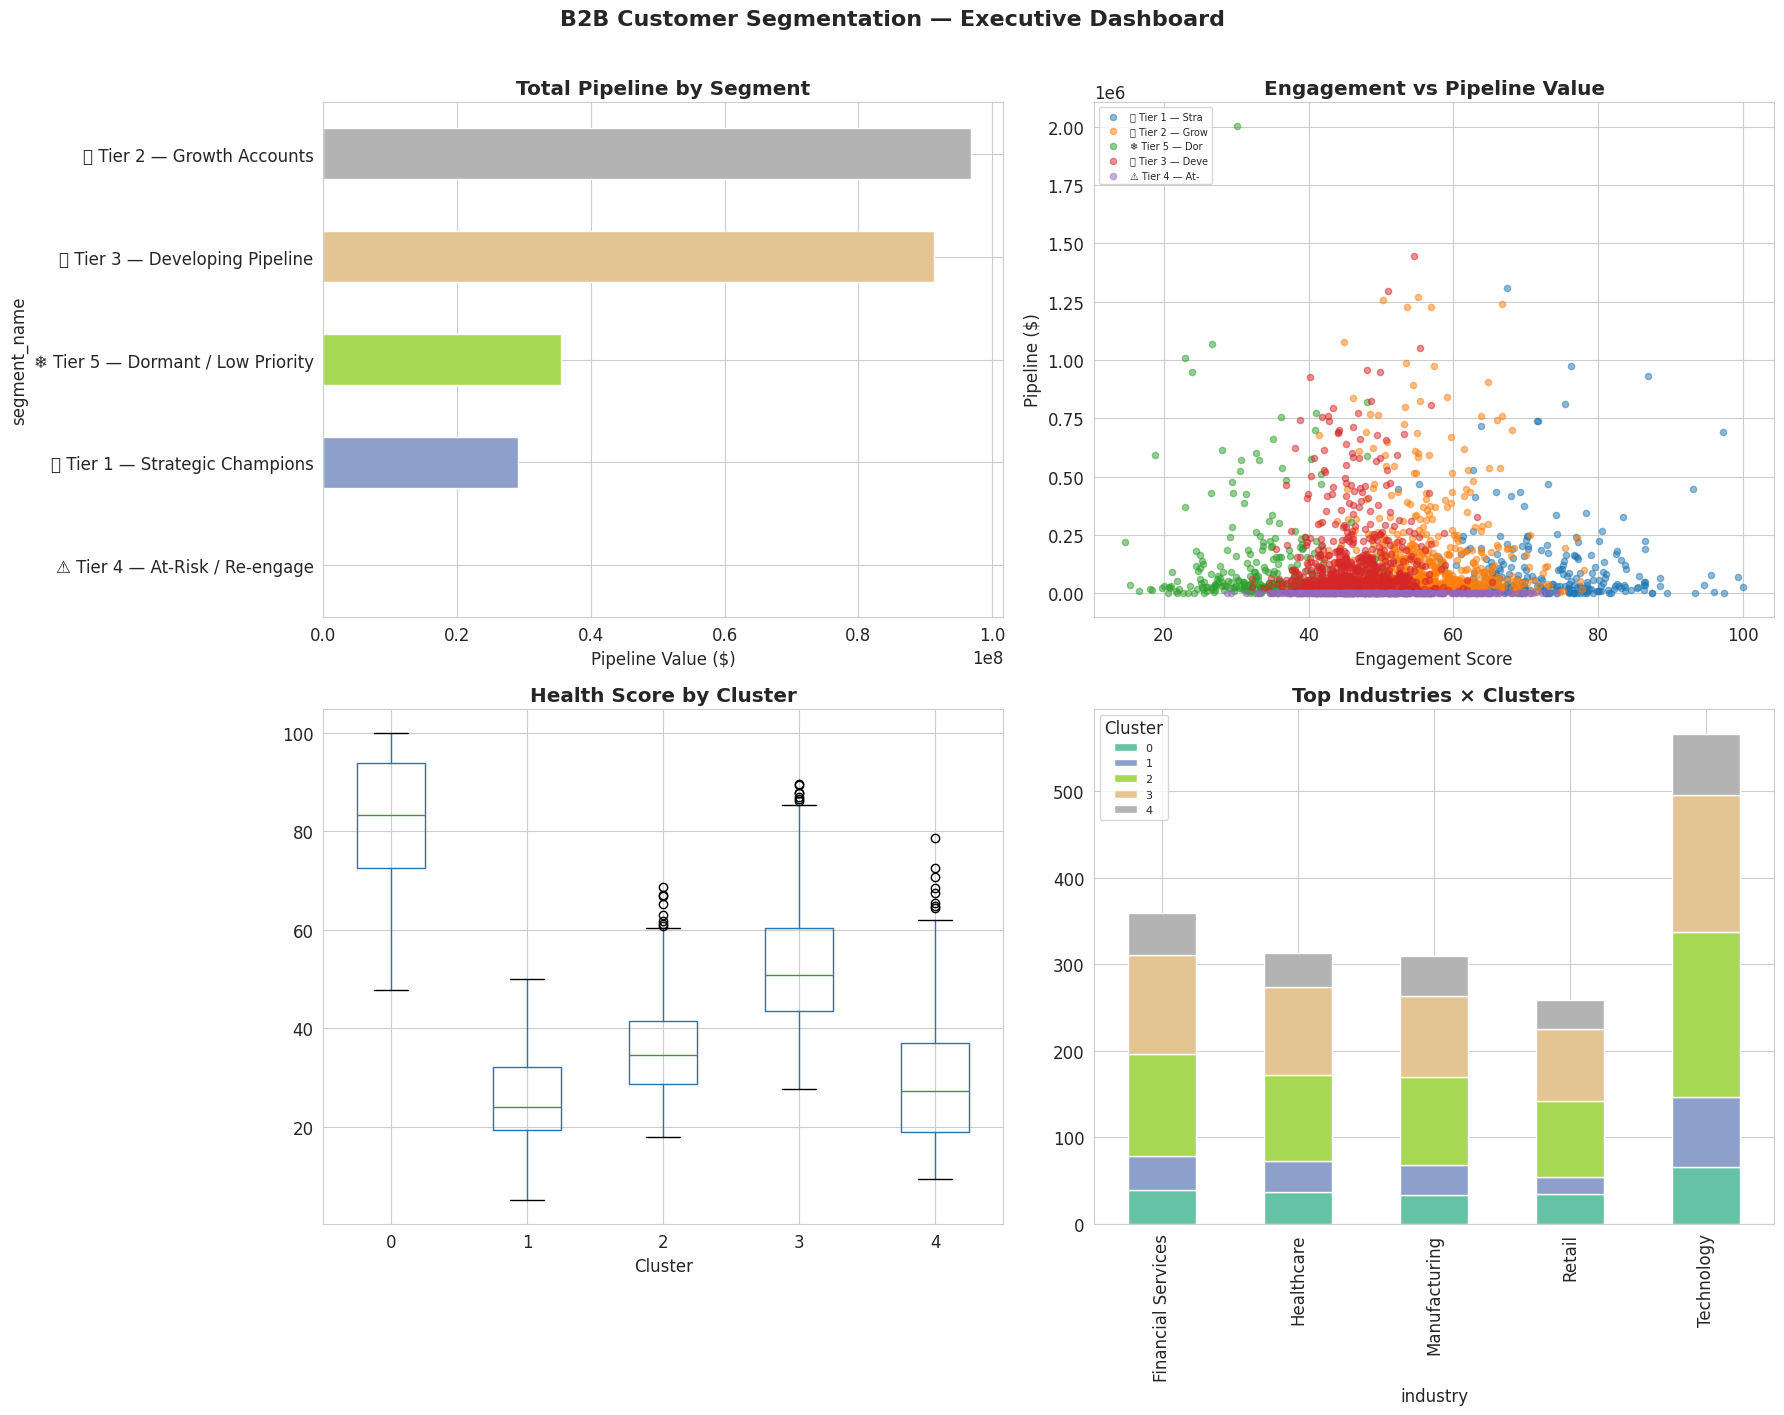


✅ B2B SEGMENTATION COMPLETE
   Total accounts segmented: 2,500
   Segments created: 5
   Methods used: RFM, K-Means, Hierarchical, DBSCAN, GMM


In [32]:
# ============================================================
# STEP 9C: Executive Dashboard Summary
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Pipeline by segment
seg_pipeline = unified_df.groupby('segment_name')['total_pipeline_value'].sum().sort_values()
seg_pipeline.plot.barh(ax=axes[0,0], color=plt.cm.Set2(np.linspace(0, 1, FINAL_K)), edgecolor='white')
axes[0,0].set_title('Total Pipeline by Segment', fontweight='bold')
axes[0,0].set_xlabel('Pipeline Value ($)')

# 2. Engagement vs Pipeline scatter
for seg in unified_df['segment_name'].unique():
    mask = unified_df['segment_name'] == seg
    axes[0,1].scatter(unified_df.loc[mask, 'engagement_score'],
                      unified_df.loc[mask, 'total_pipeline_value'],
                      label=seg[:15], s=20, alpha=0.5)
axes[0,1].set_title('Engagement vs Pipeline Value', fontweight='bold')
axes[0,1].set_xlabel('Engagement Score'); axes[0,1].set_ylabel('Pipeline ($)')
axes[0,1].legend(fontsize=7, loc='upper left')

# 3. Health score distribution by segment
unified_df.boxplot(column='health_score', by='kmeans_cluster', ax=axes[1,0])
axes[1,0].set_title('Health Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('Cluster')
plt.sca(axes[1,0]); plt.title('Health Score by Cluster', fontweight='bold')

# 4. Industry breakdown per segment
top_industries = unified_df['industry'].value_counts().head(5).index
ind_seg = unified_df[unified_df['industry'].isin(top_industries)].groupby(
    ['industry', 'kmeans_cluster']).size().unstack(fill_value=0)
ind_seg.plot.bar(ax=axes[1,1], stacked=True, colormap='Set2', edgecolor='white')
axes[1,1].set_title('Top Industries × Clusters', fontweight='bold')
axes[1,1].legend(title='Cluster', fontsize=8)

plt.suptitle('B2B Customer Segmentation — Executive Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n✅ B2B SEGMENTATION COMPLETE')
print(f'   Total accounts segmented: {len(unified_df):,}')
print(f'   Segments created: {FINAL_K}')
print(f'   Methods used: RFM, K-Means, Hierarchical, DBSCAN, GMM')